In [1]:
import os
import sys
sys.path.append(os.path.abspath('.'))
import mkssins
from mkssins import *
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import matplotlib as mpl
mpl.rcParams['font.size'] = 16
mpl.rcParams['figure.facecolor'] = 'None'

In [2]:
# create waterfalls 


In [3]:
import os
import pickle

folder_path = 'ssins_iterative_flags/ssins_level0/'  # Replace with your folder path
data_ssins_round1 = {}
fname = []

for filename in os.listdir(folder_path):
      if filename.endswith('_h_ssins_Level0_flags.pickle') or filename.endswith('_h_ssins_Level0_flags.npy'):
        print(filename)
        file_prefix = filename.split('_')[0] 
        file_path = os.path.join(folder_path, filename)
        with open(file_path, 'rb') as file:
            data_ssins_round1[file_prefix] = np.load(file)
            fname.append(file_prefix)
        
print(f"Loaded {len(data_ssins_round1)} pickle files.")

1634402485_h_ssins_Level0_flags.npy
1634252028_h_ssins_Level0_flags.npy
1638130295_h_ssins_Level0_flags.npy
1637691677_h_ssins_Level0_flags.npy
1631732038_h_ssins_Level0_flags.npy
1632077222_h_ssins_Level0_flags.npy
1631667564_h_ssins_Level0_flags.npy
1638294319_h_ssins_Level0_flags.npy
1637354605_h_ssins_Level0_flags.npy
1638386189_h_ssins_Level0_flags.npy
1630519596_h_ssins_Level0_flags.npy
1638639082_h_ssins_Level0_flags.npy
1632184922_h_ssins_Level0_flags.npy
1631990463_h_ssins_Level0_flags.npy
1638301944_h_ssins_Level0_flags.npy
1631559762_h_ssins_Level0_flags.npy
1637346562_h_ssins_Level0_flags.npy
1639157507_h_ssins_Level0_flags.npy
1631818149_h_ssins_Level0_flags.npy
1631387336_h_ssins_Level0_flags.npy
1637699408_h_ssins_Level0_flags.npy
1632069690_h_ssins_Level0_flags.npy
1631982988_h_ssins_Level0_flags.npy
1631810671_h_ssins_Level0_flags.npy
1632760885_h_ssins_Level0_flags.npy
1640799689_h_ssins_Level0_flags.npy
Loaded 26 pickle files.


In [4]:
import os
import pickle

folder_path = 'ssins_iterative_flags/ssins_level1/'  # Replace with your folder path
data_ssins_round2 = {}
fname = []

for filename in os.listdir(folder_path):
      if filename.endswith('_h_ssins_Level1_flags.pickle') or filename.endswith('_h_ssins_Level1_flags.npy'):
        print(filename)
        file_prefix = filename.split('_')[0] 
        file_path = os.path.join(folder_path, filename)
        with open(file_path, 'rb') as file:
            data_ssins_round2[file_prefix] = np.load(file)
            fname.append(file_prefix)
        
print(f"Loaded {len(data_ssins_round2)} pickle files.")

1638294319_h_ssins_Level1_flags.npy
1638386189_h_ssins_Level1_flags.npy
1632069690_h_ssins_Level1_flags.npy
1631818149_h_ssins_Level1_flags.npy
1631982988_h_ssins_Level1_flags.npy
1631667564_h_ssins_Level1_flags.npy
1639157507_h_ssins_Level1_flags.npy
1632077222_h_ssins_Level1_flags.npy
1637691677_h_ssins_Level1_flags.npy
1638639082_h_ssins_Level1_flags.npy
1637699408_h_ssins_Level1_flags.npy
1631732038_h_ssins_Level1_flags.npy
1640799689_h_ssins_Level1_flags.npy
1631990463_h_ssins_Level1_flags.npy
1631387336_h_ssins_Level1_flags.npy
1637354605_h_ssins_Level1_flags.npy
1638130295_h_ssins_Level1_flags.npy
1638301944_h_ssins_Level1_flags.npy
1634402485_h_ssins_Level1_flags.npy
1631559762_h_ssins_Level1_flags.npy
1632760885_h_ssins_Level1_flags.npy
1637346562_h_ssins_Level1_flags.npy
1634252028_h_ssins_Level1_flags.npy
1630519596_h_ssins_Level1_flags.npy
1632184922_h_ssins_Level1_flags.npy
1631810671_h_ssins_Level1_flags.npy
Loaded 26 pickle files.


1634402485


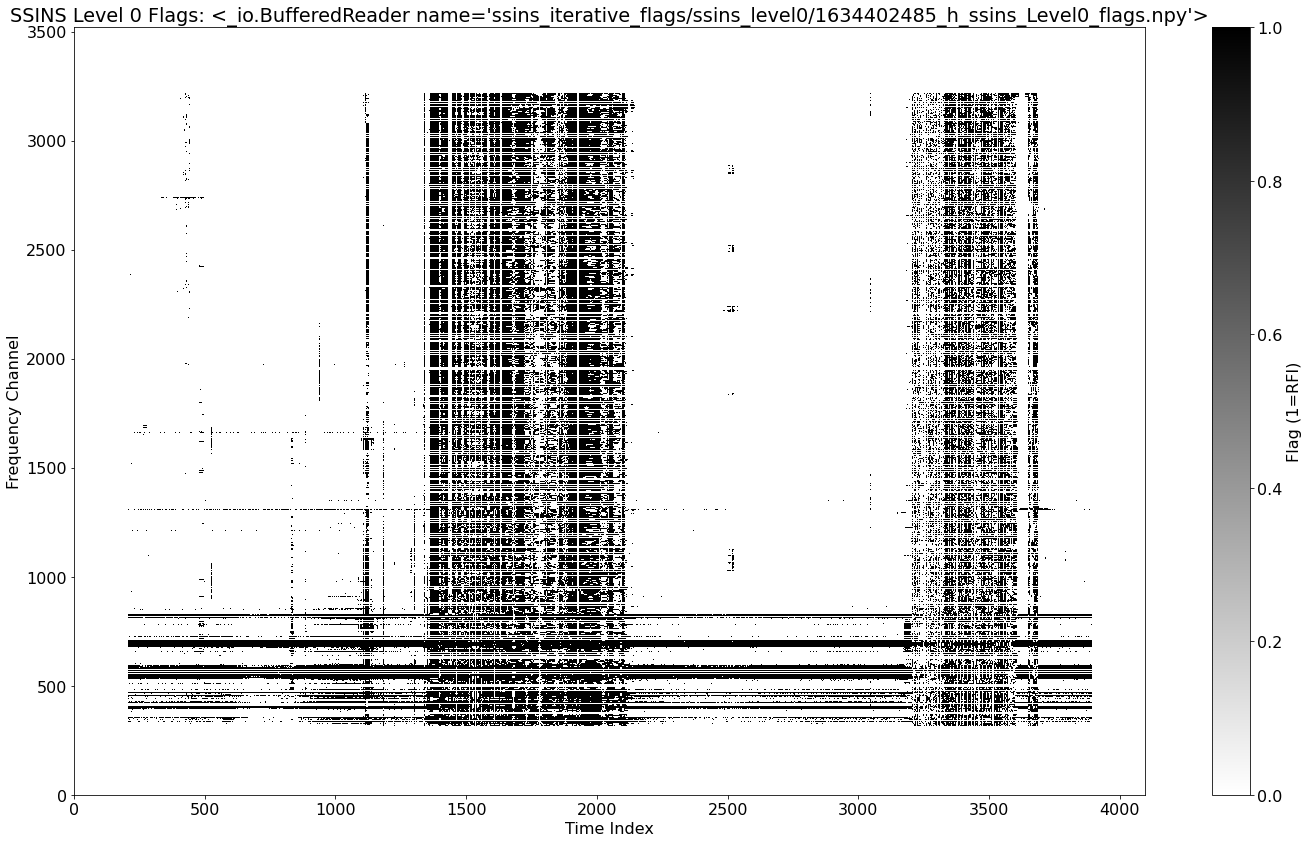

1634252028


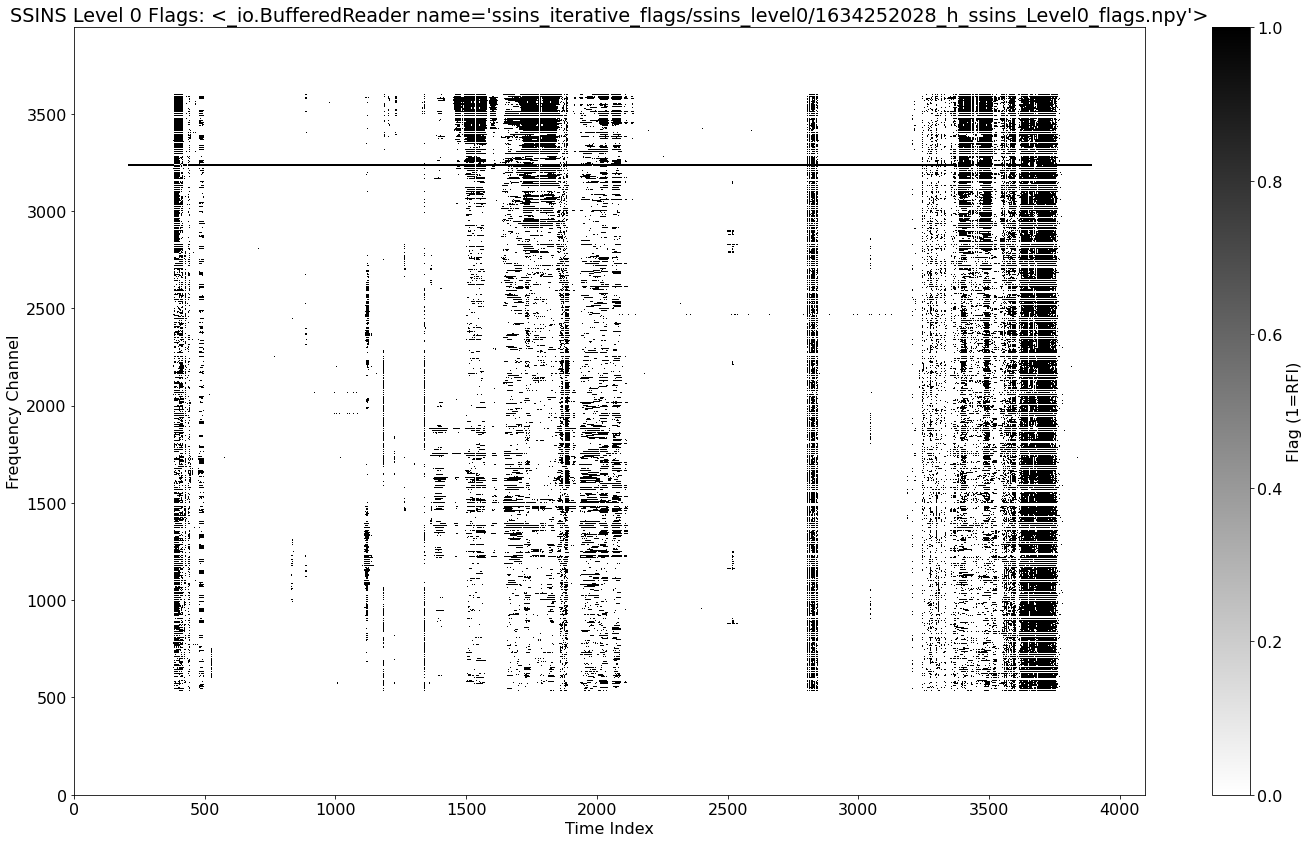

1638130295


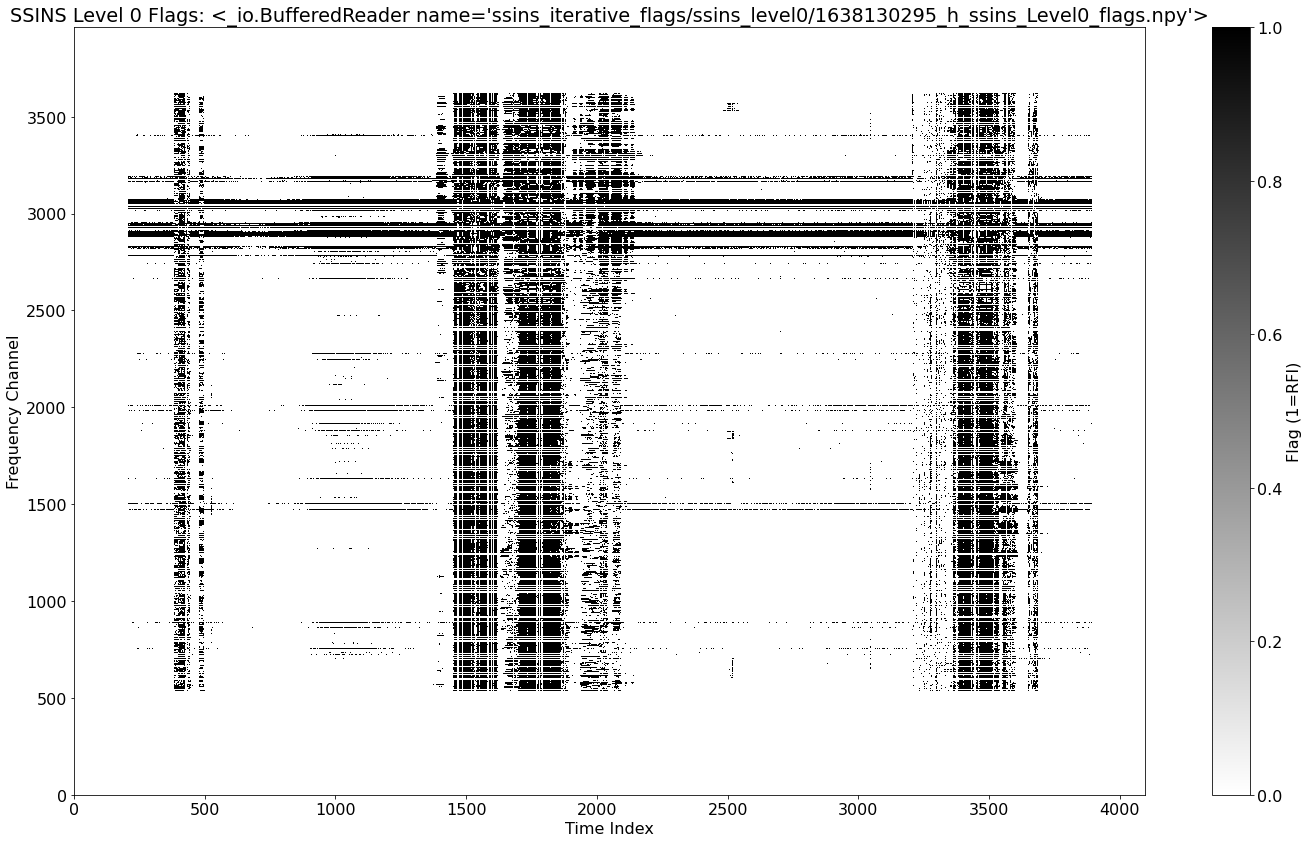

1637691677


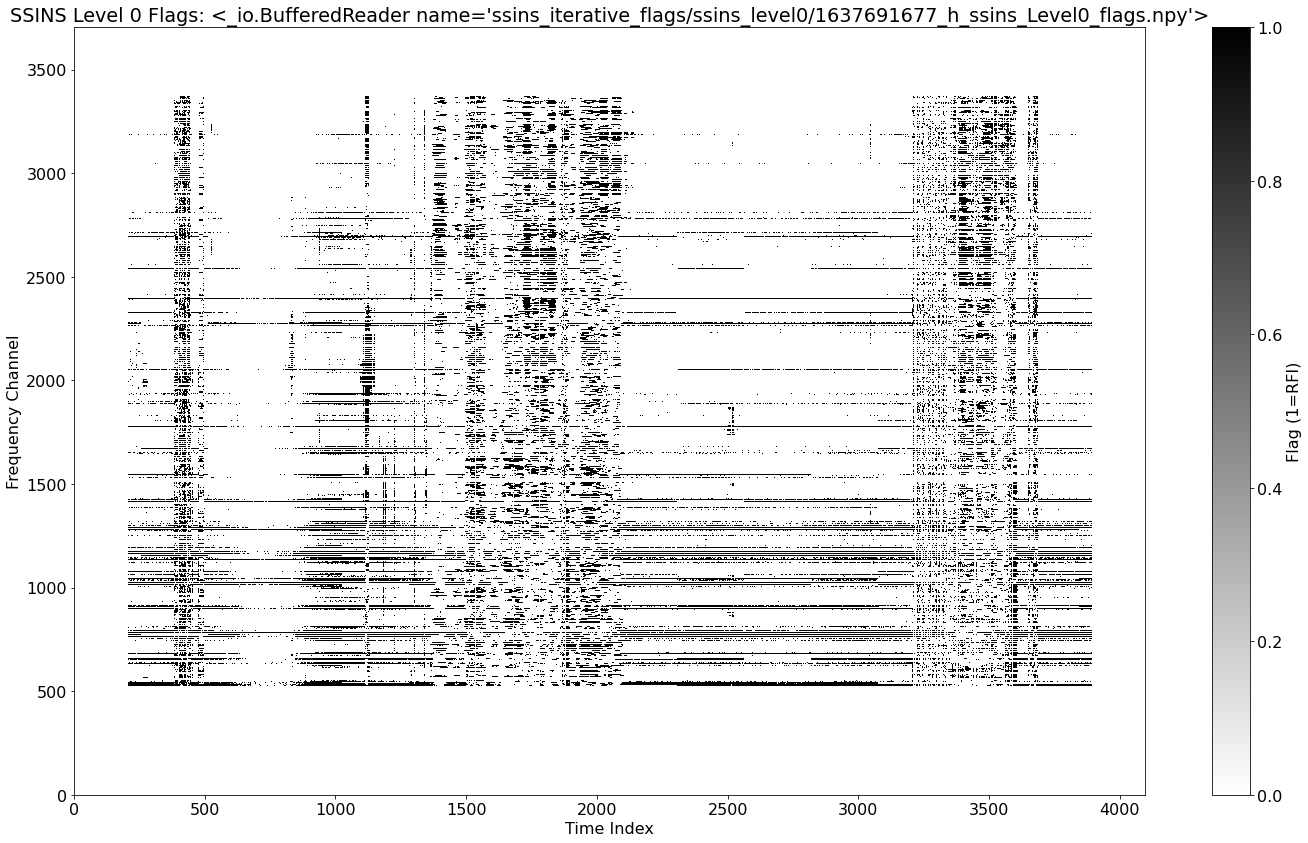

1631732038


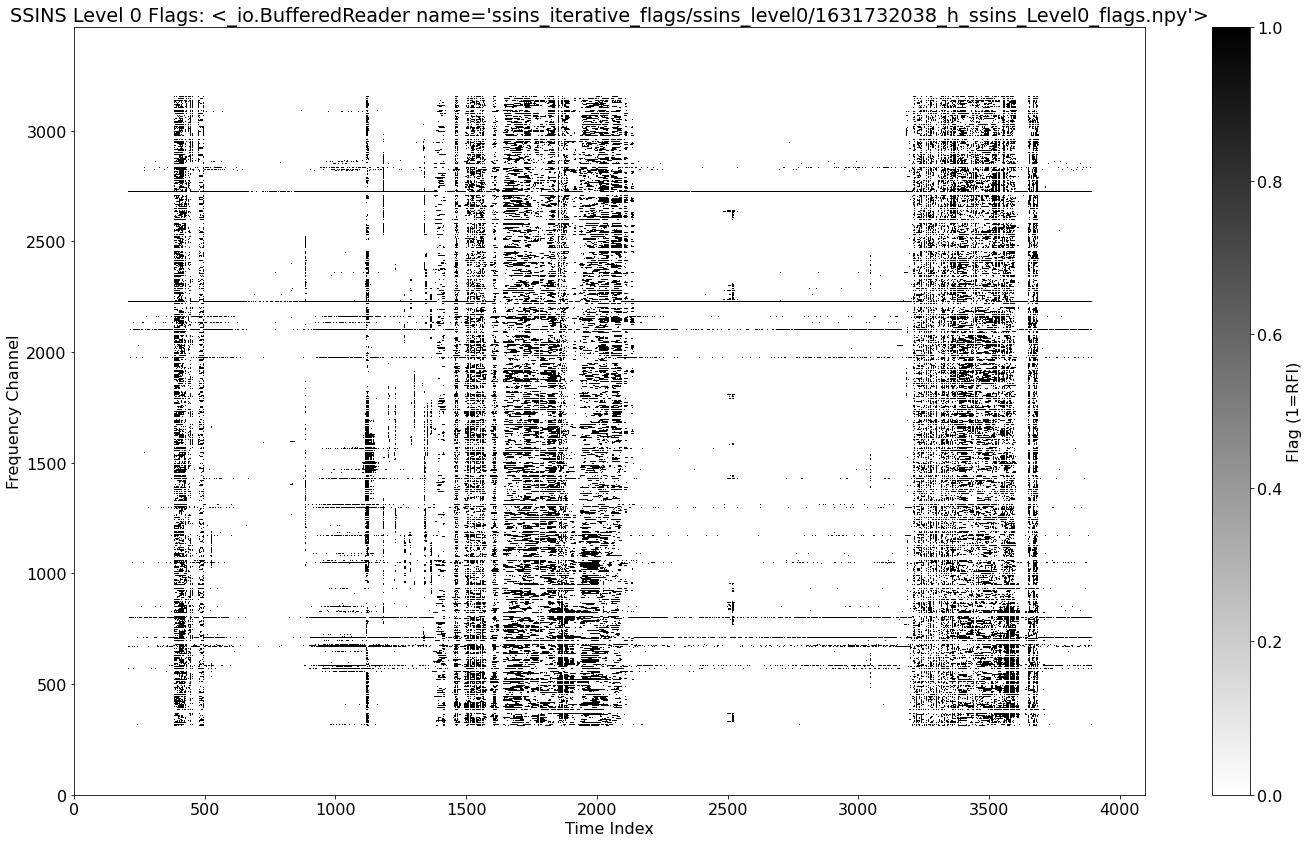

1632077222


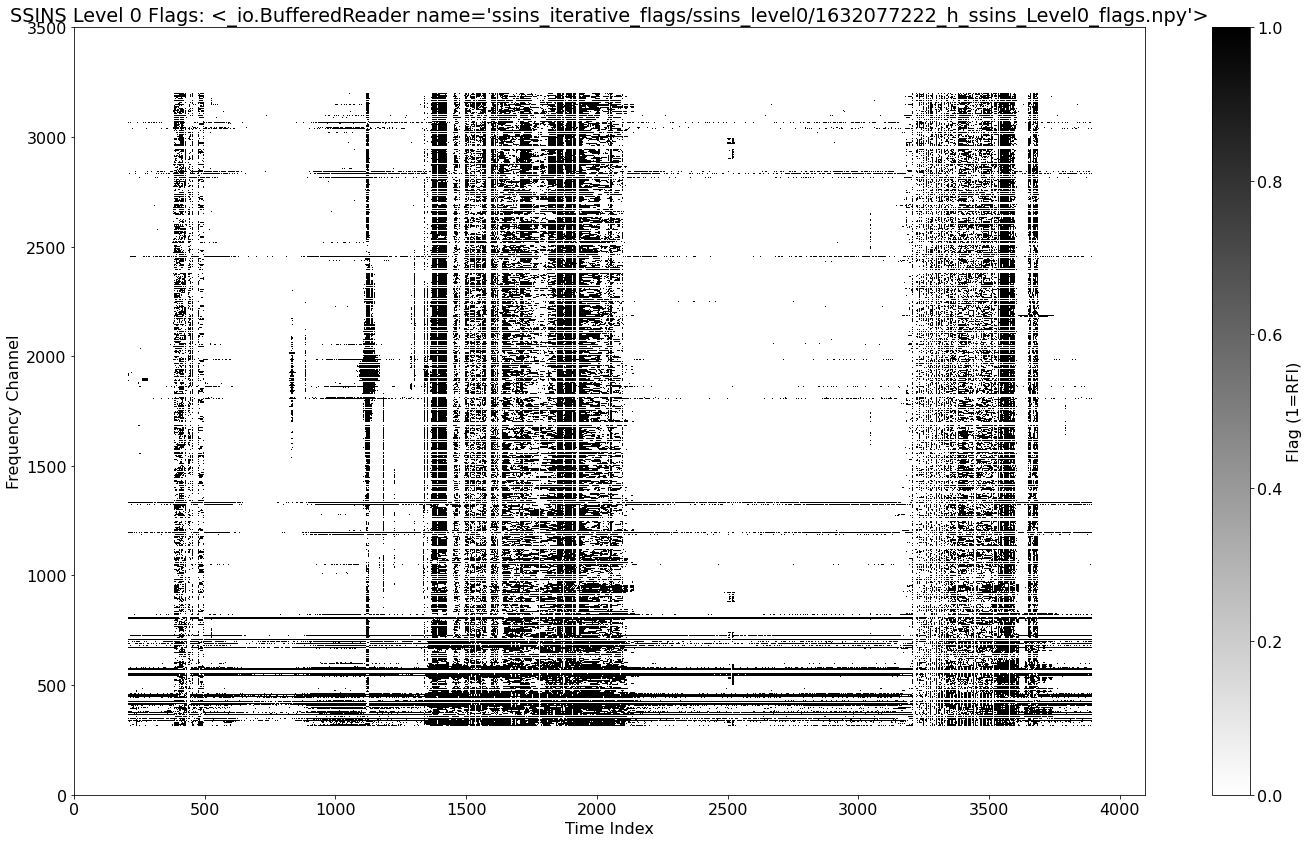

1631667564


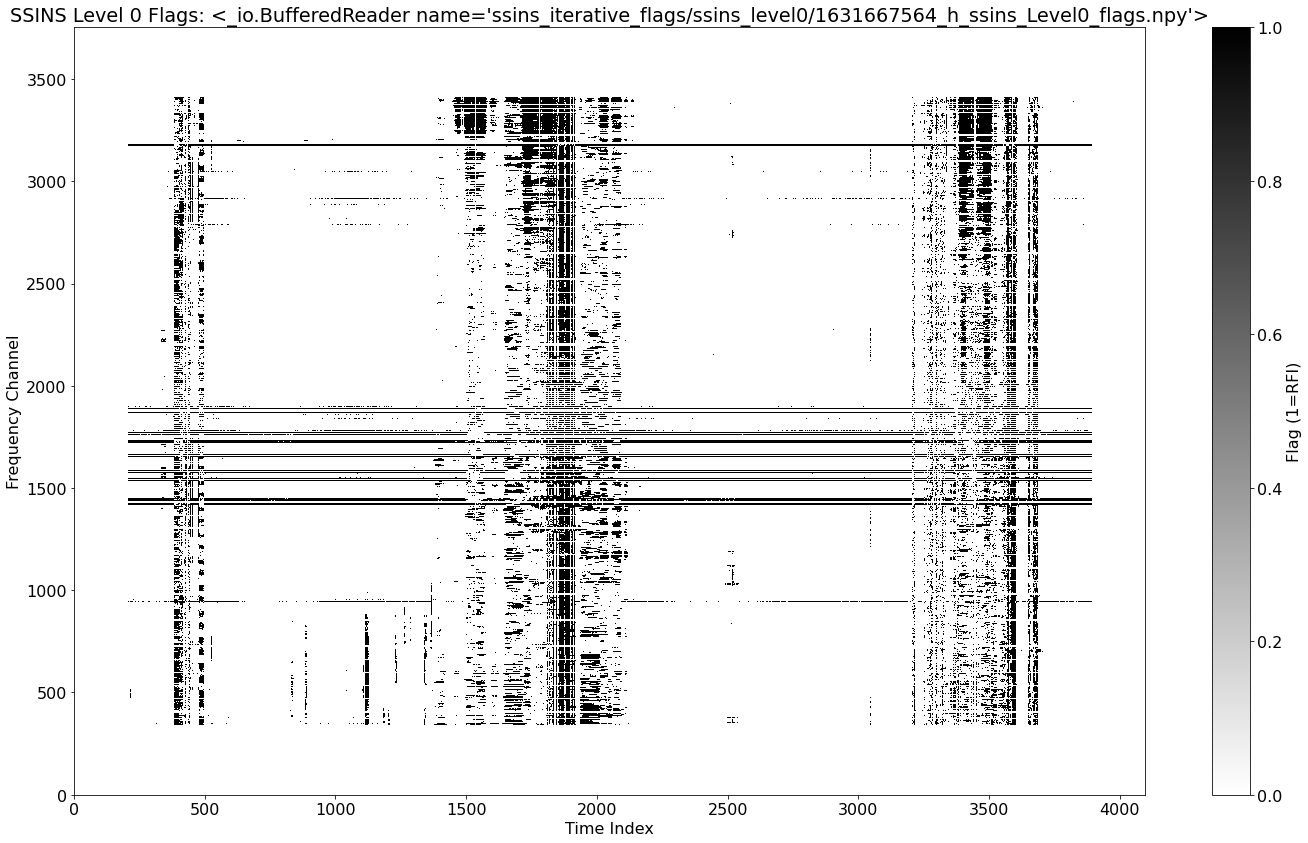

1638294319


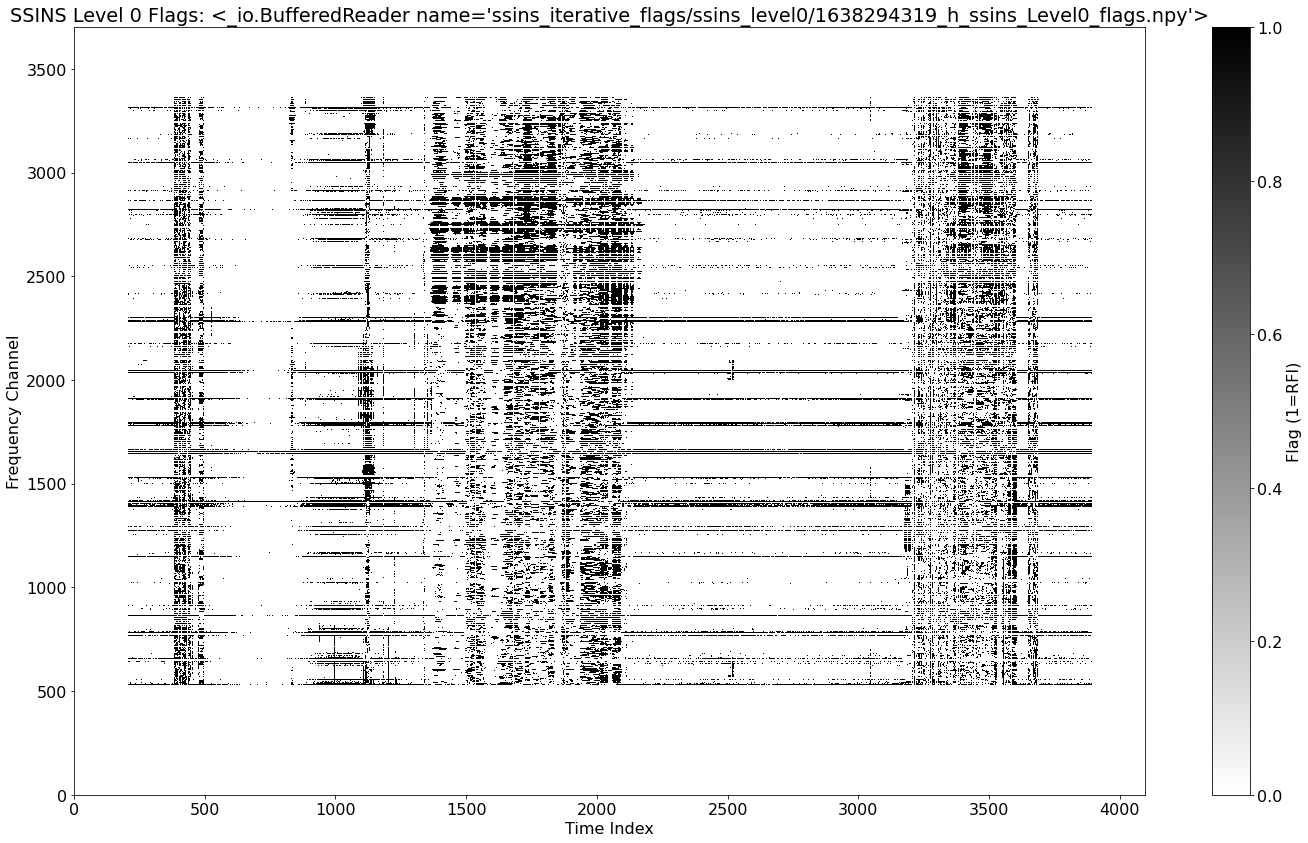

1637354605


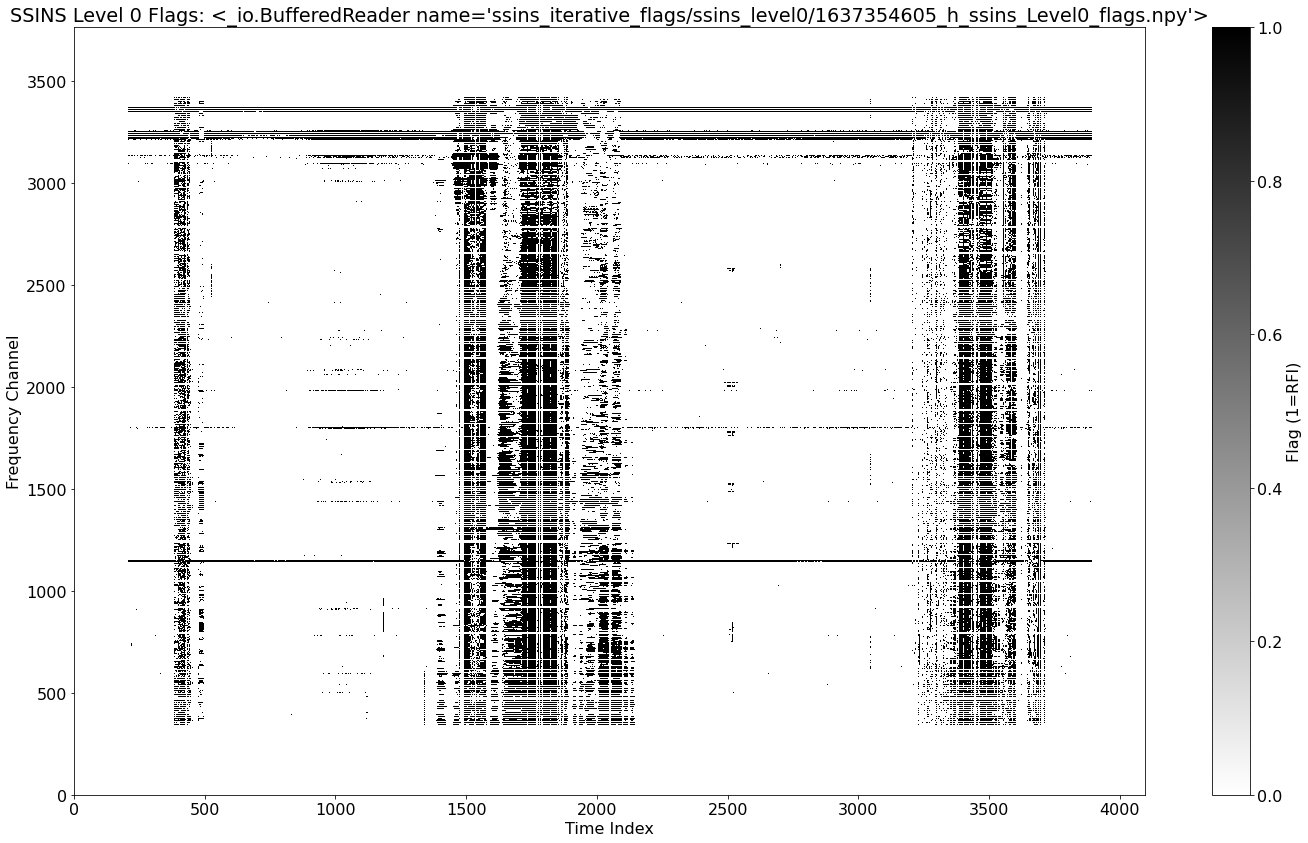

1638386189


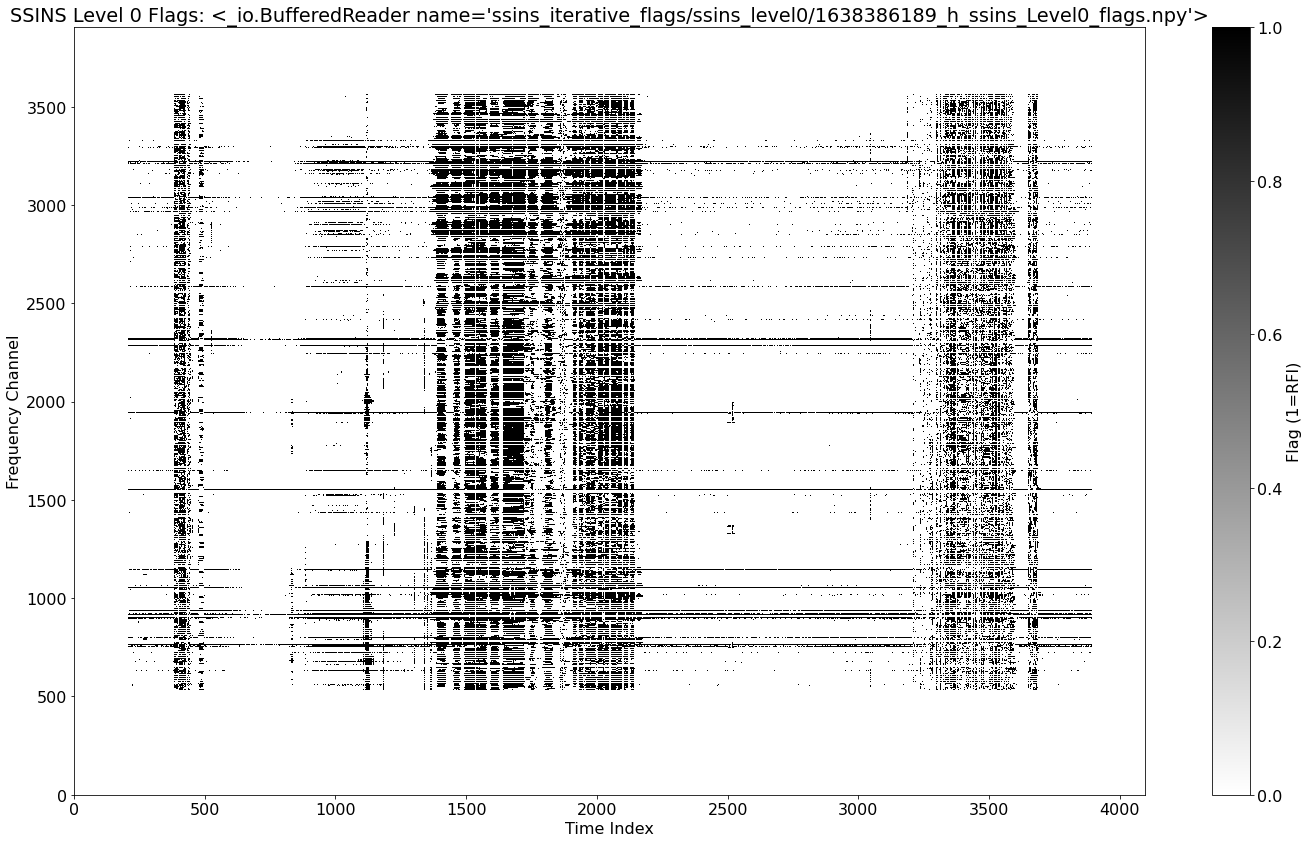

1630519596


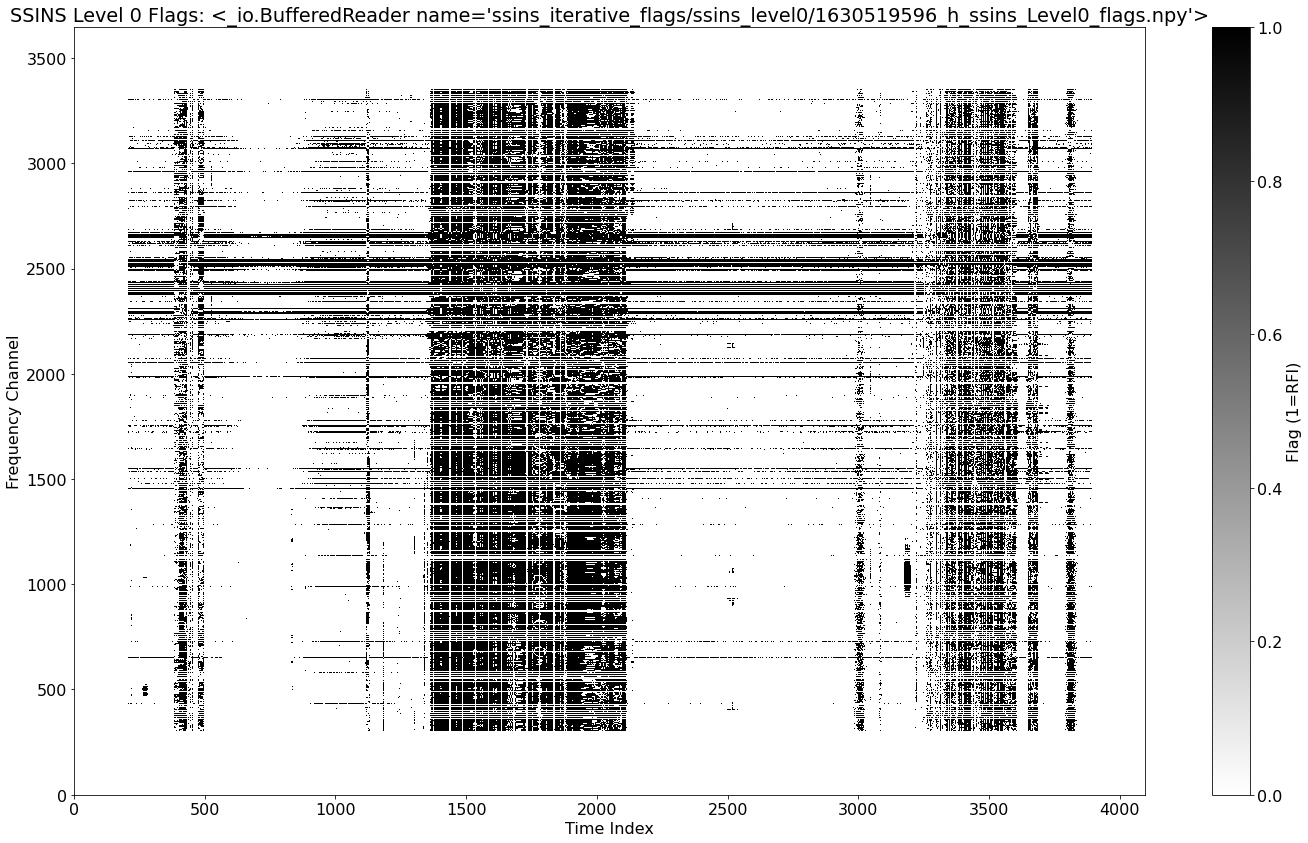

1638639082


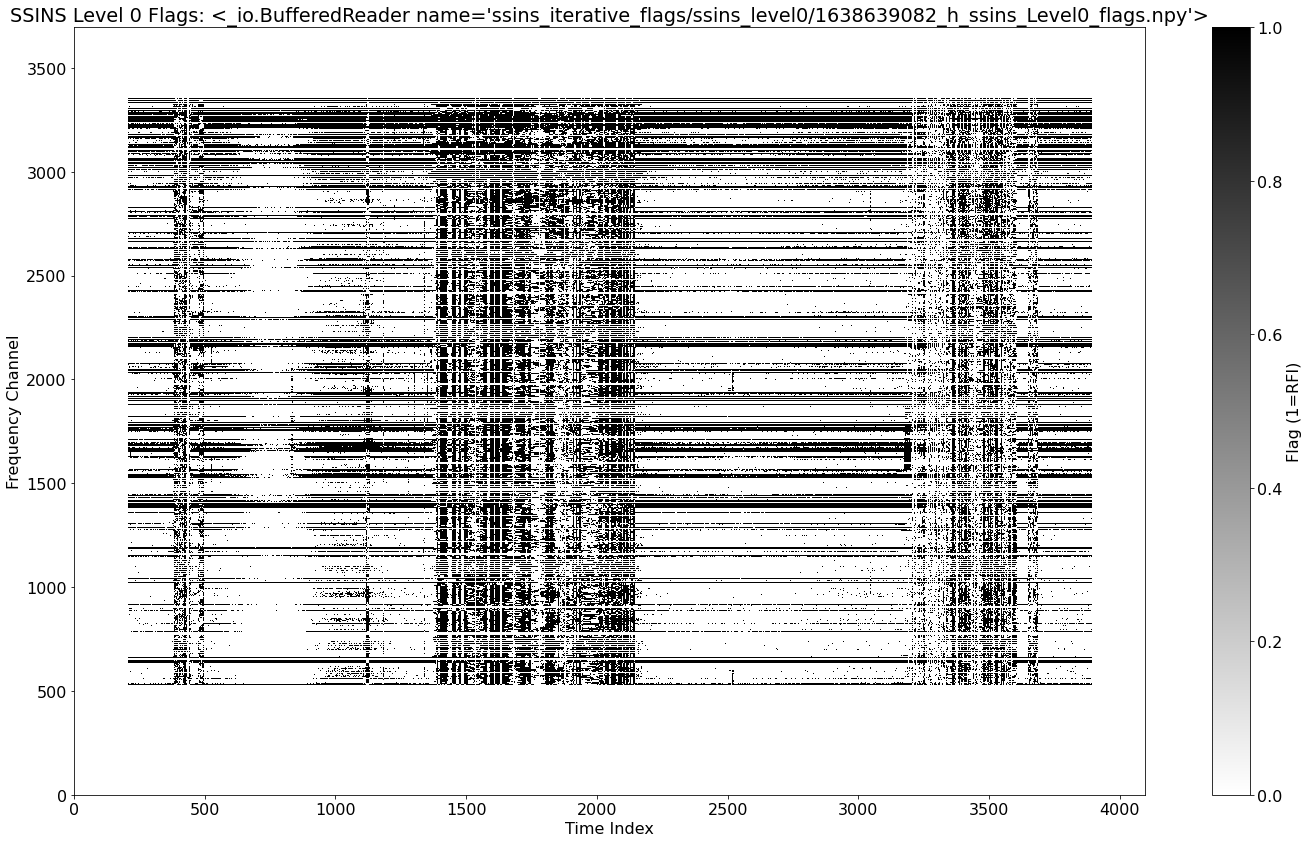

1632184922


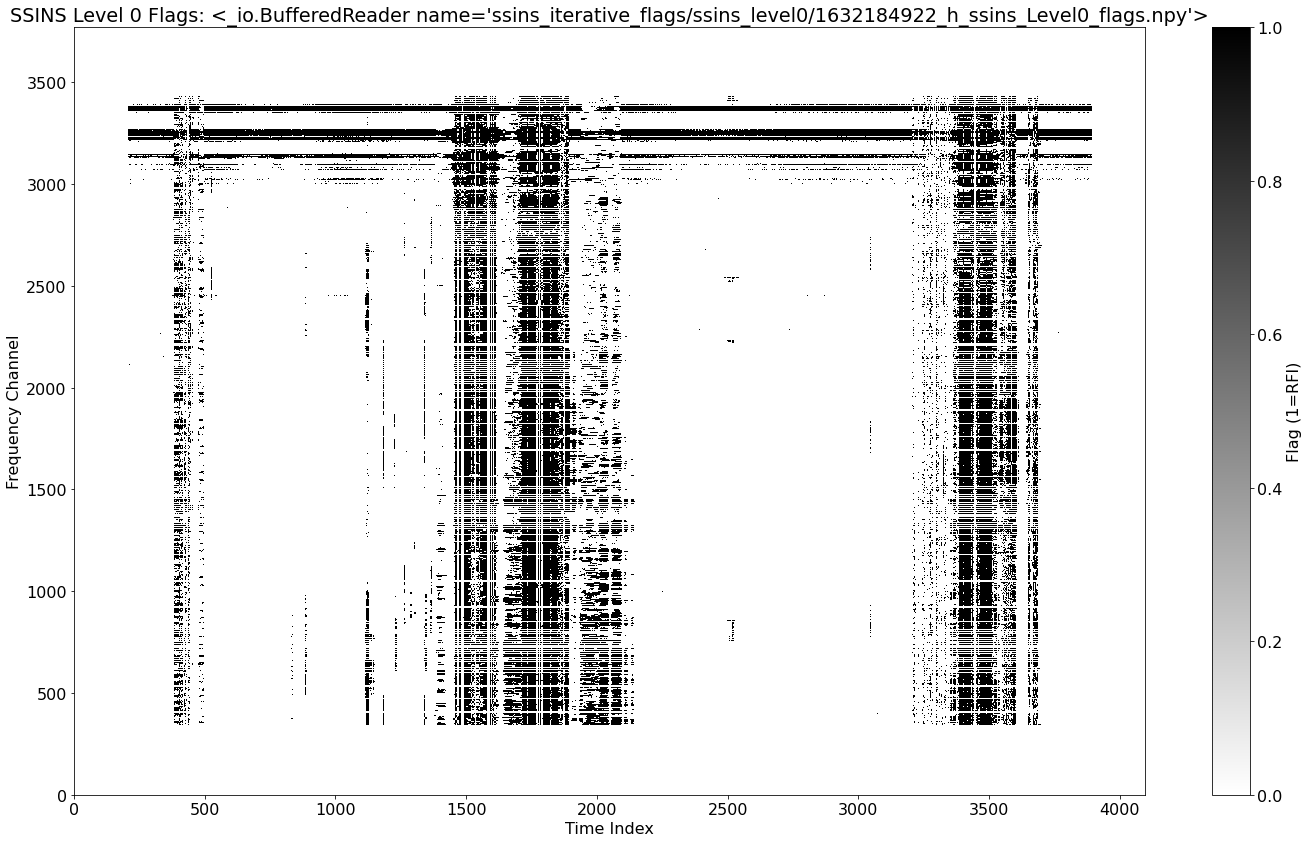

1631990463


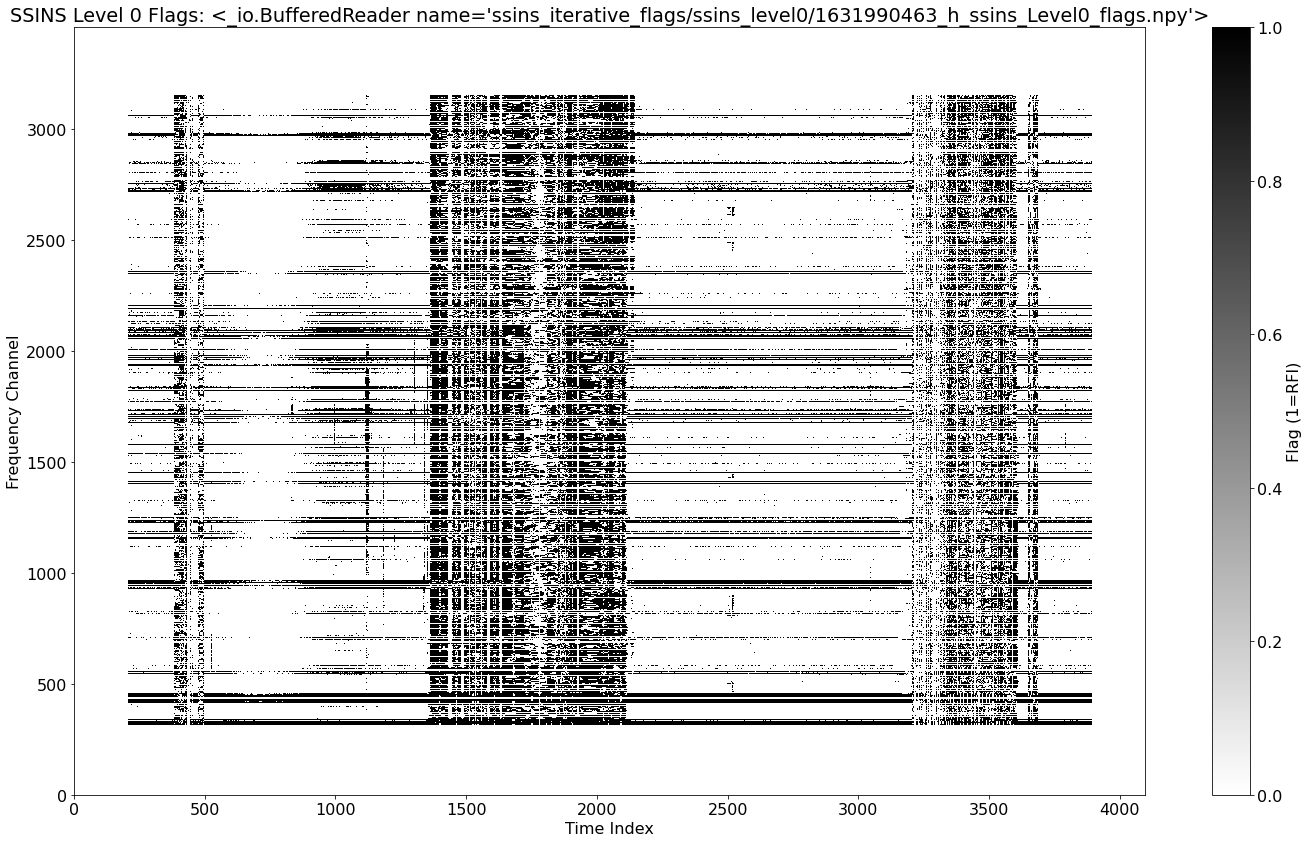

1638301944


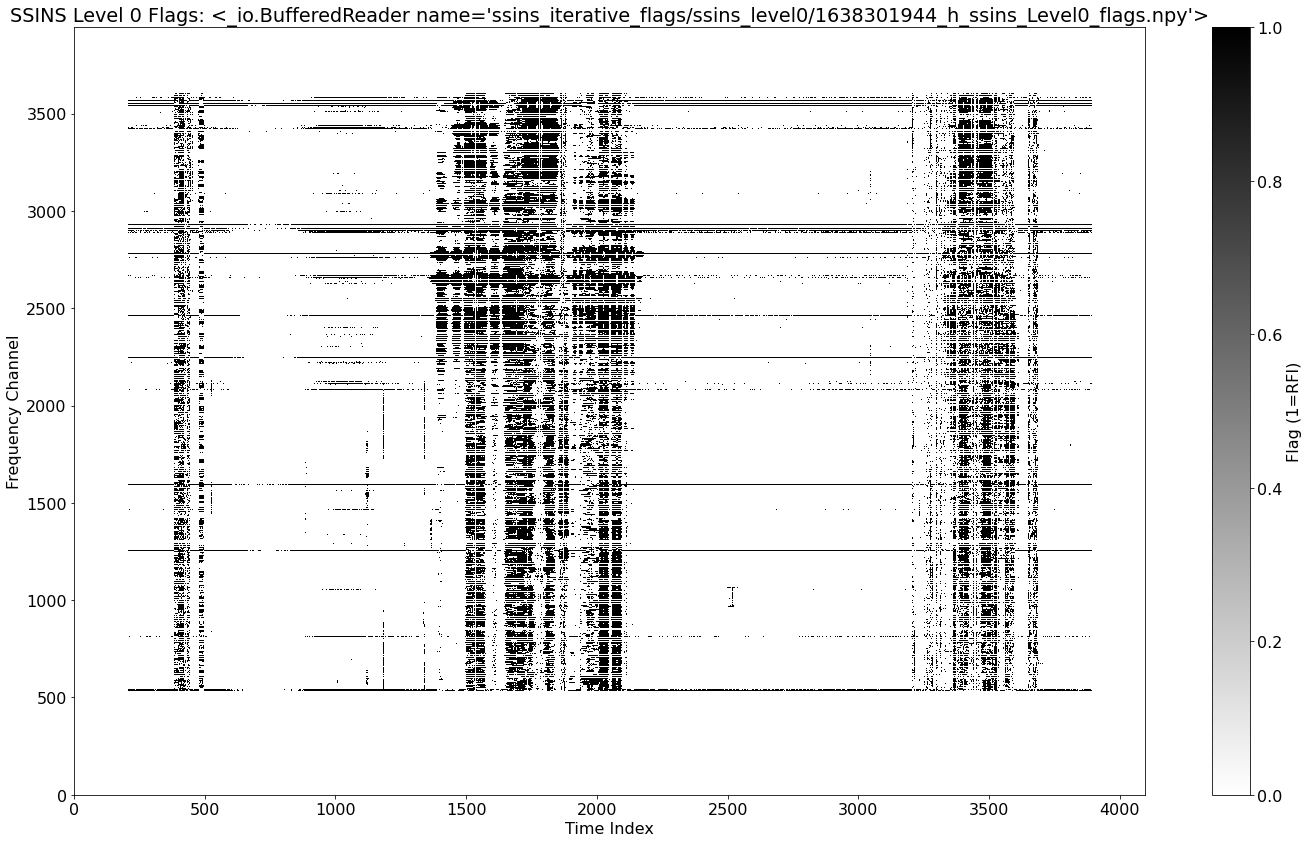

1631559762


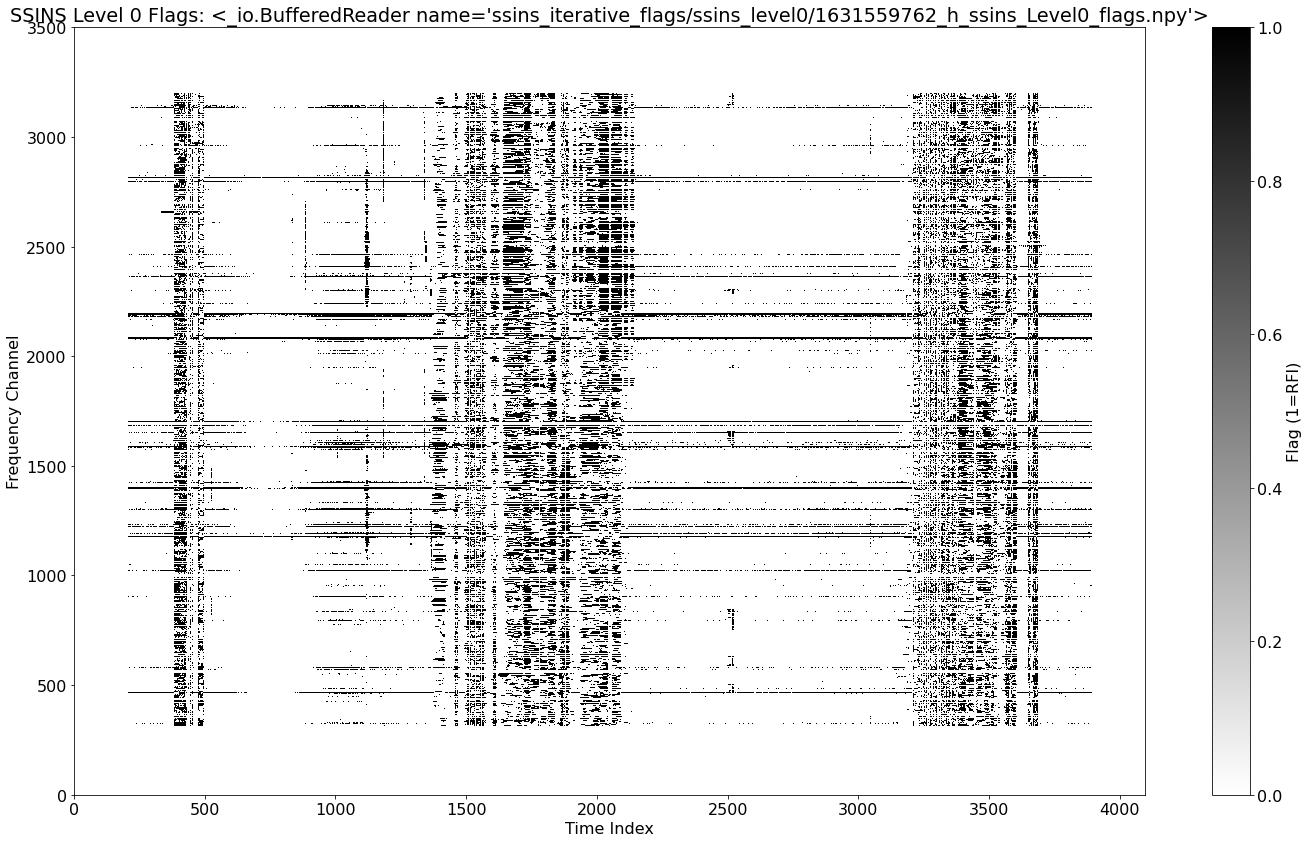

1637346562


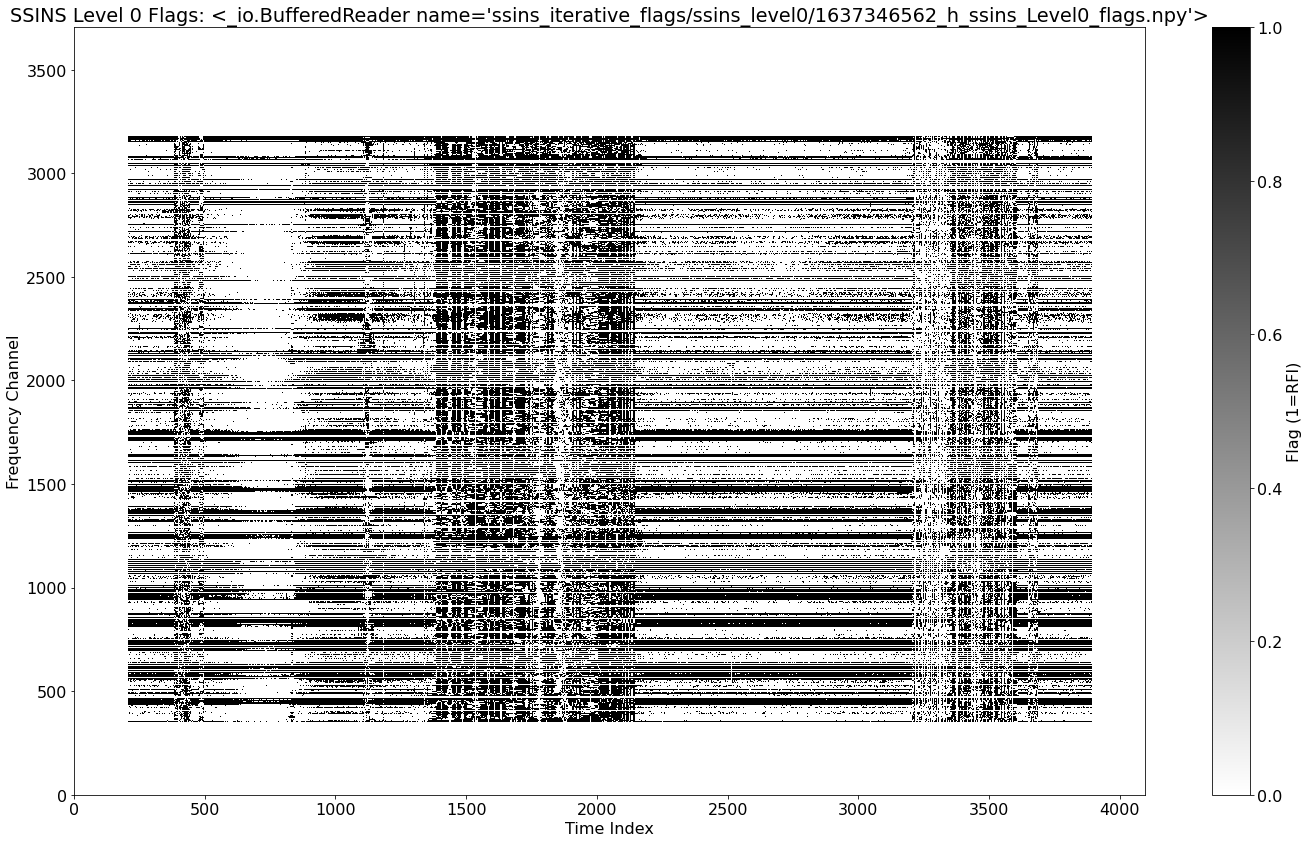

1639157507


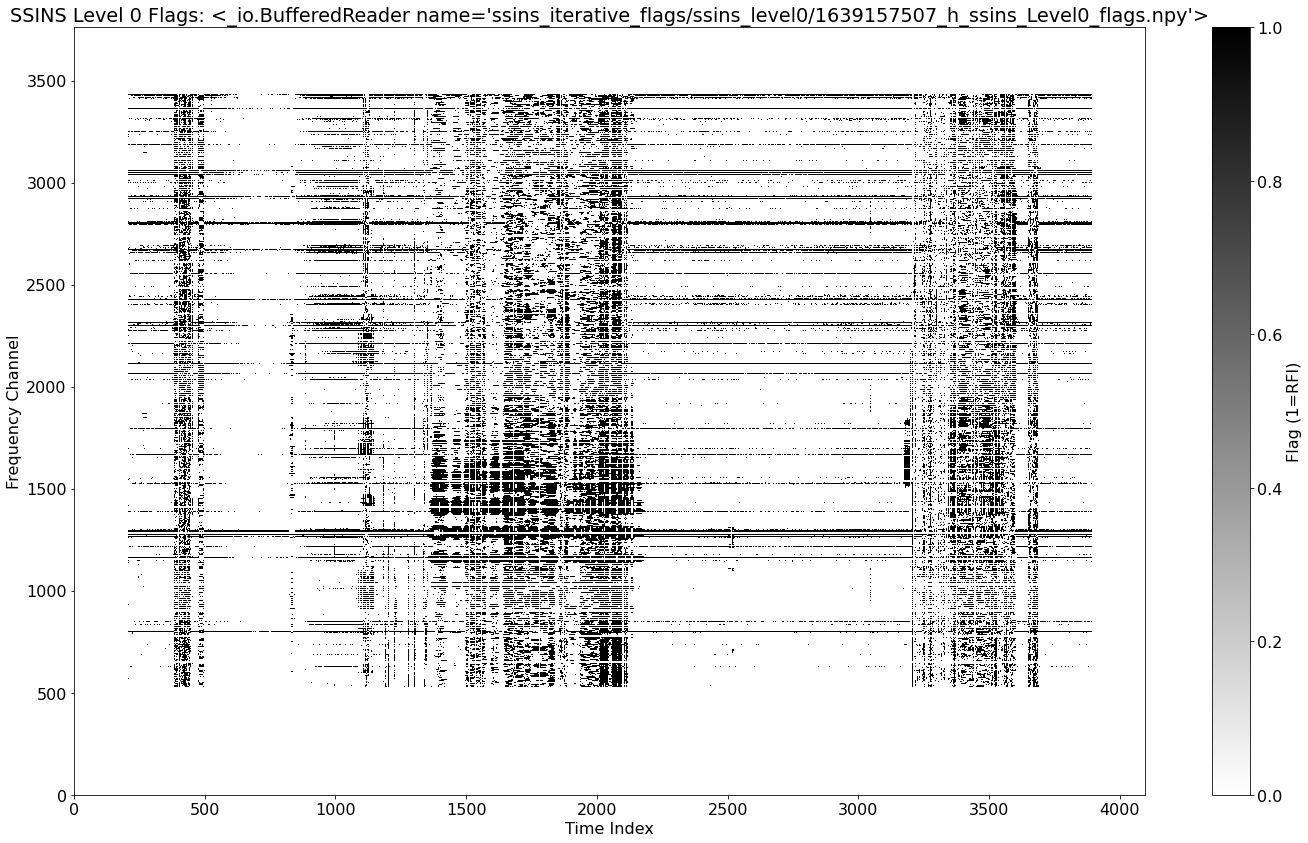

1631818149


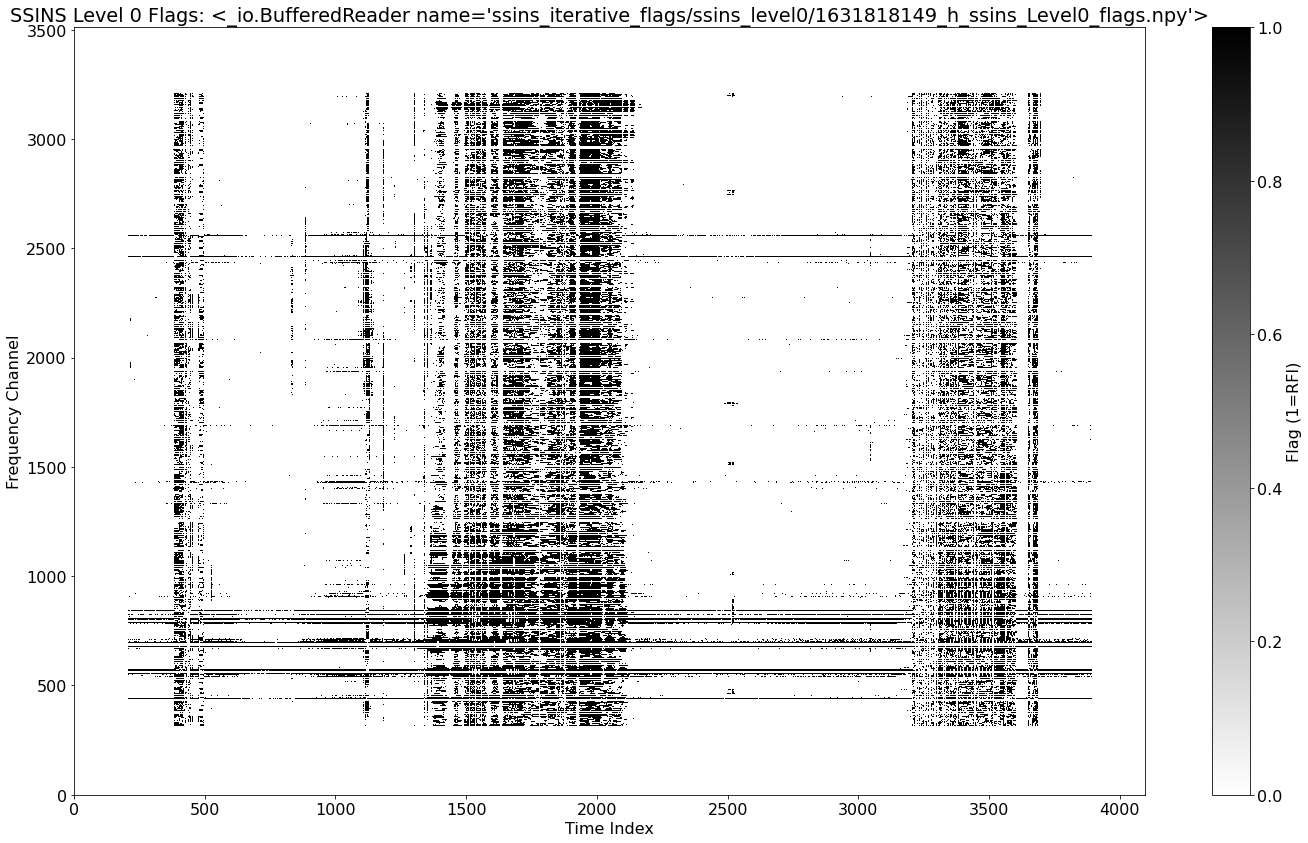

1631387336


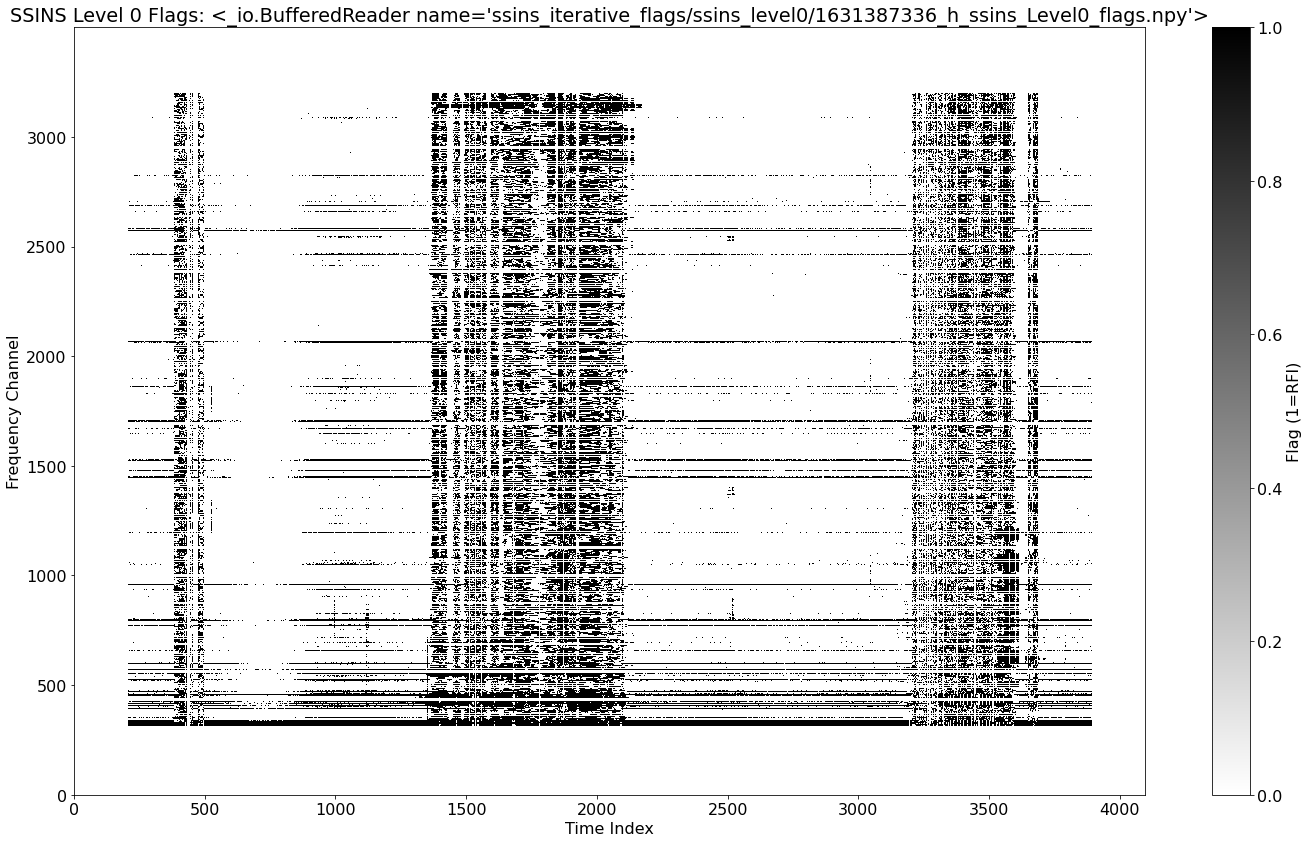

1637699408


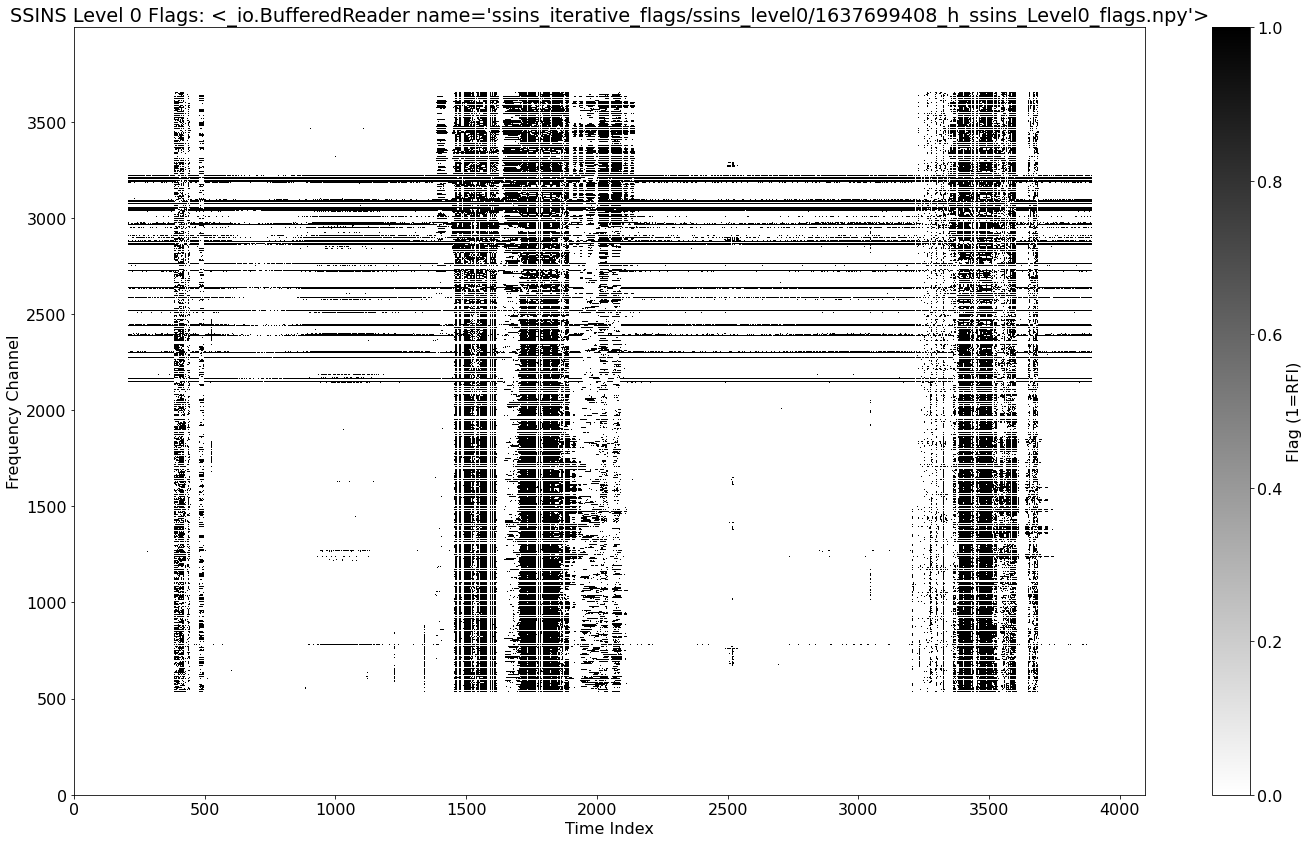

1632069690


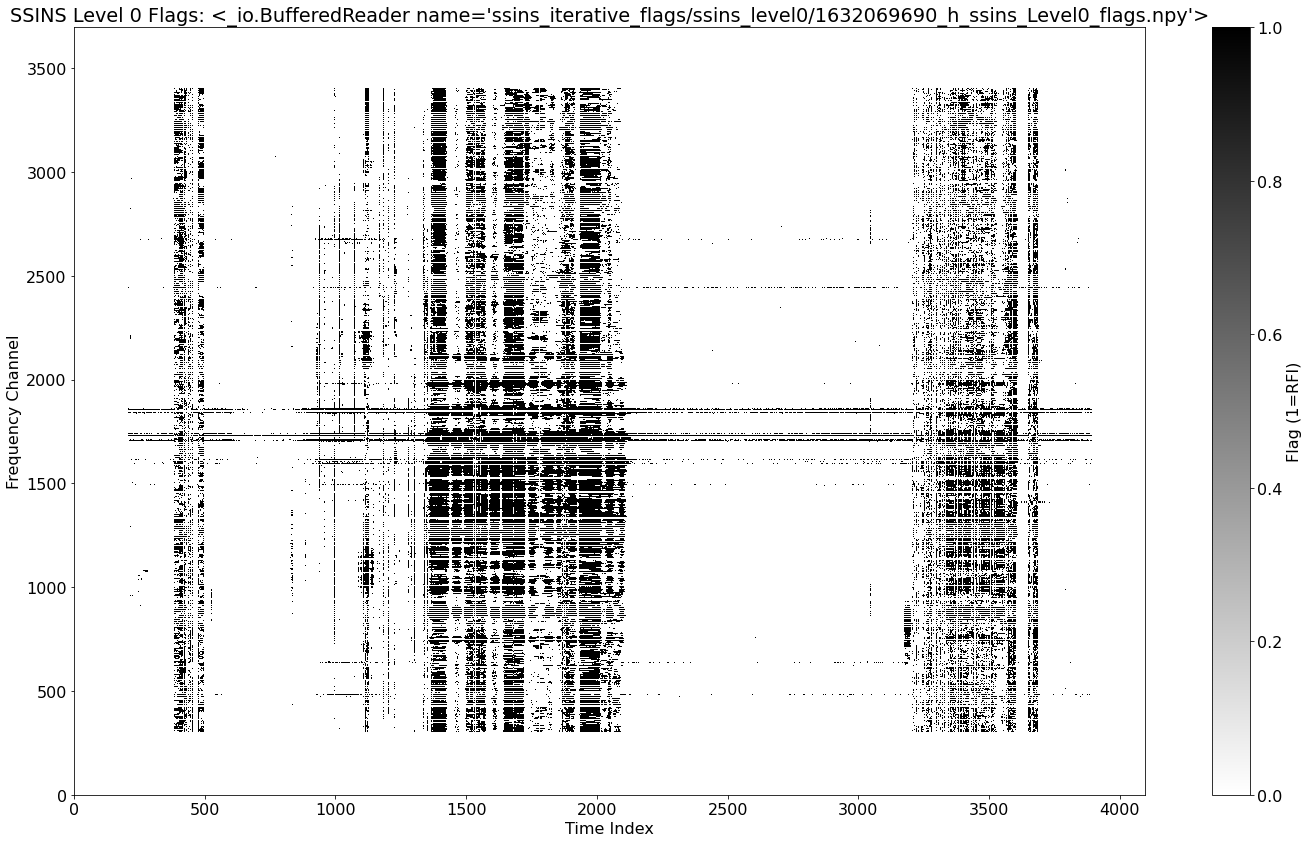

1631982988


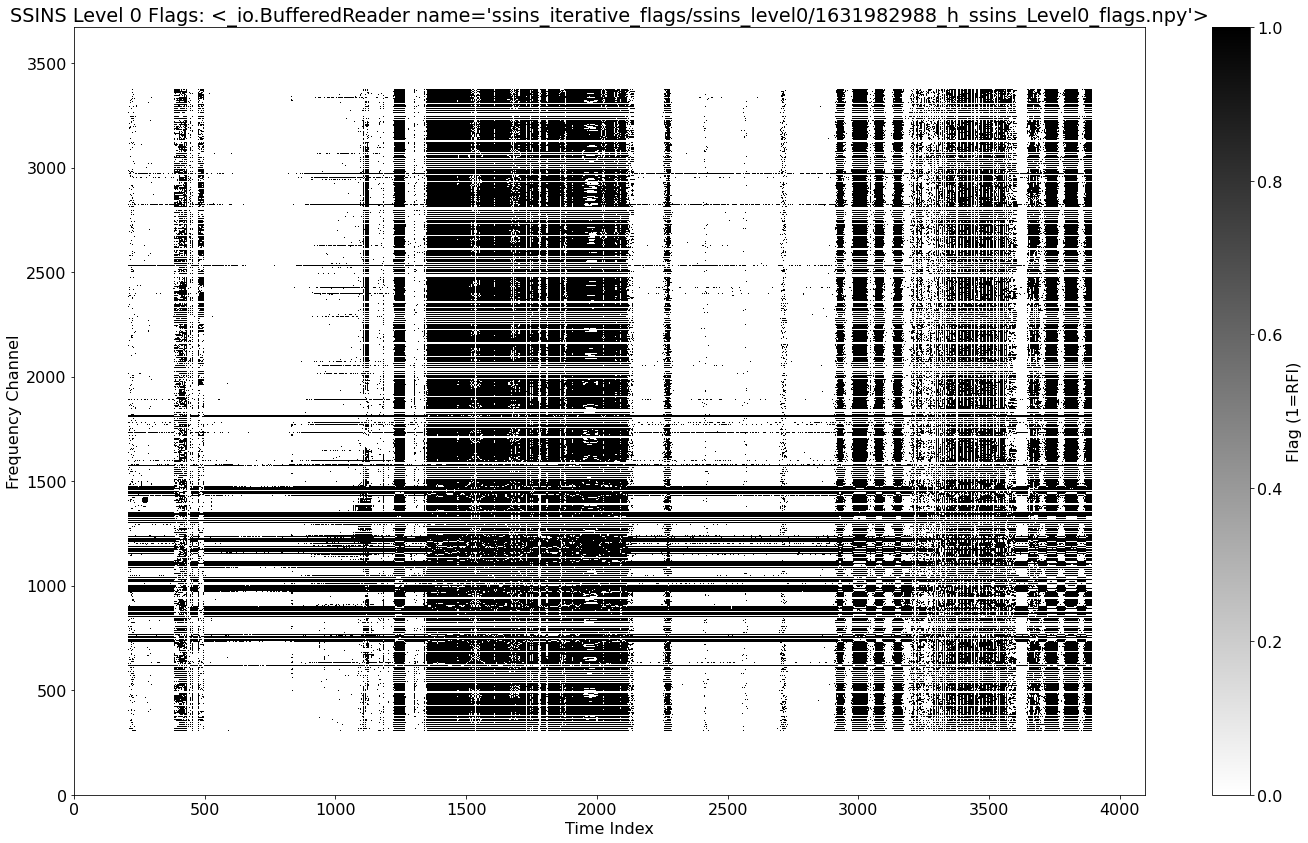

1631810671


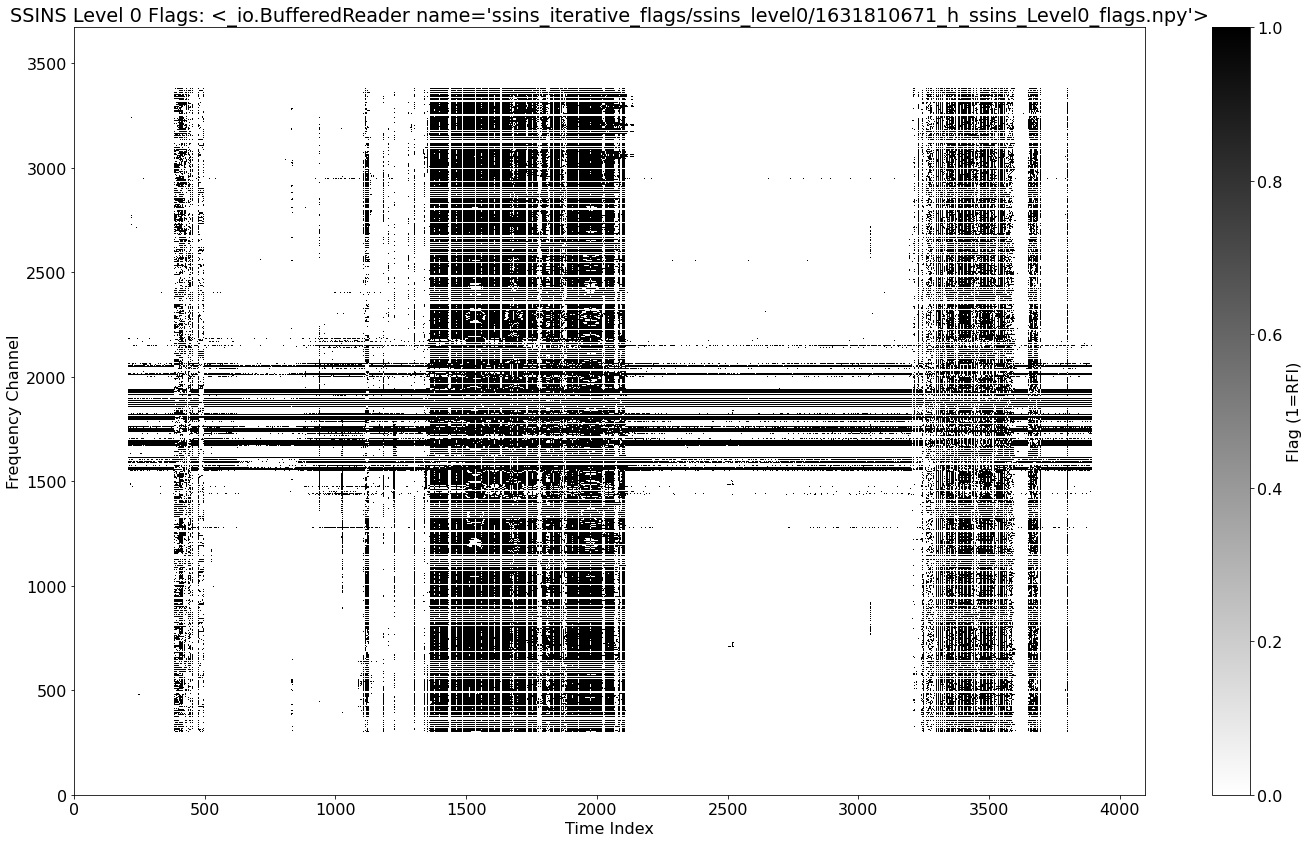

1632760885


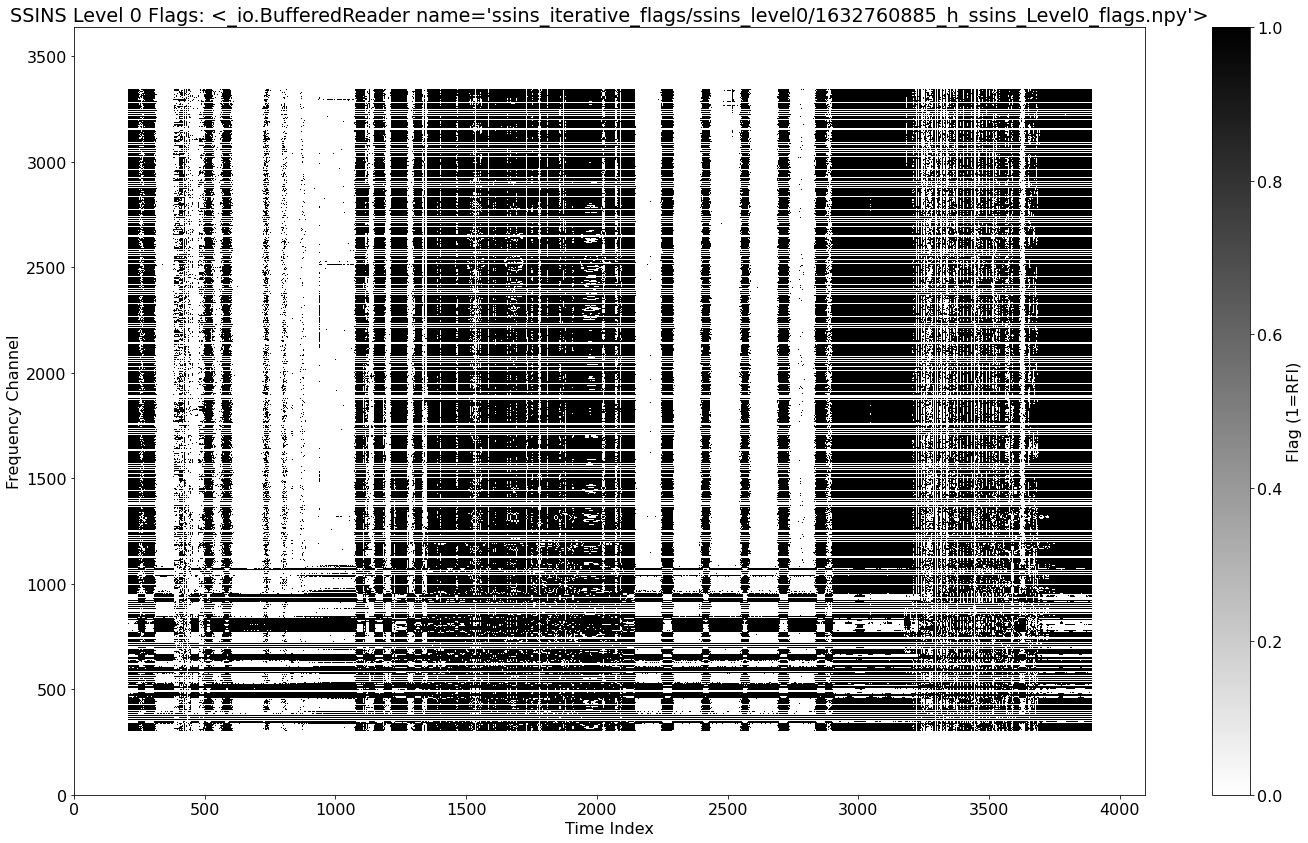

1640799689


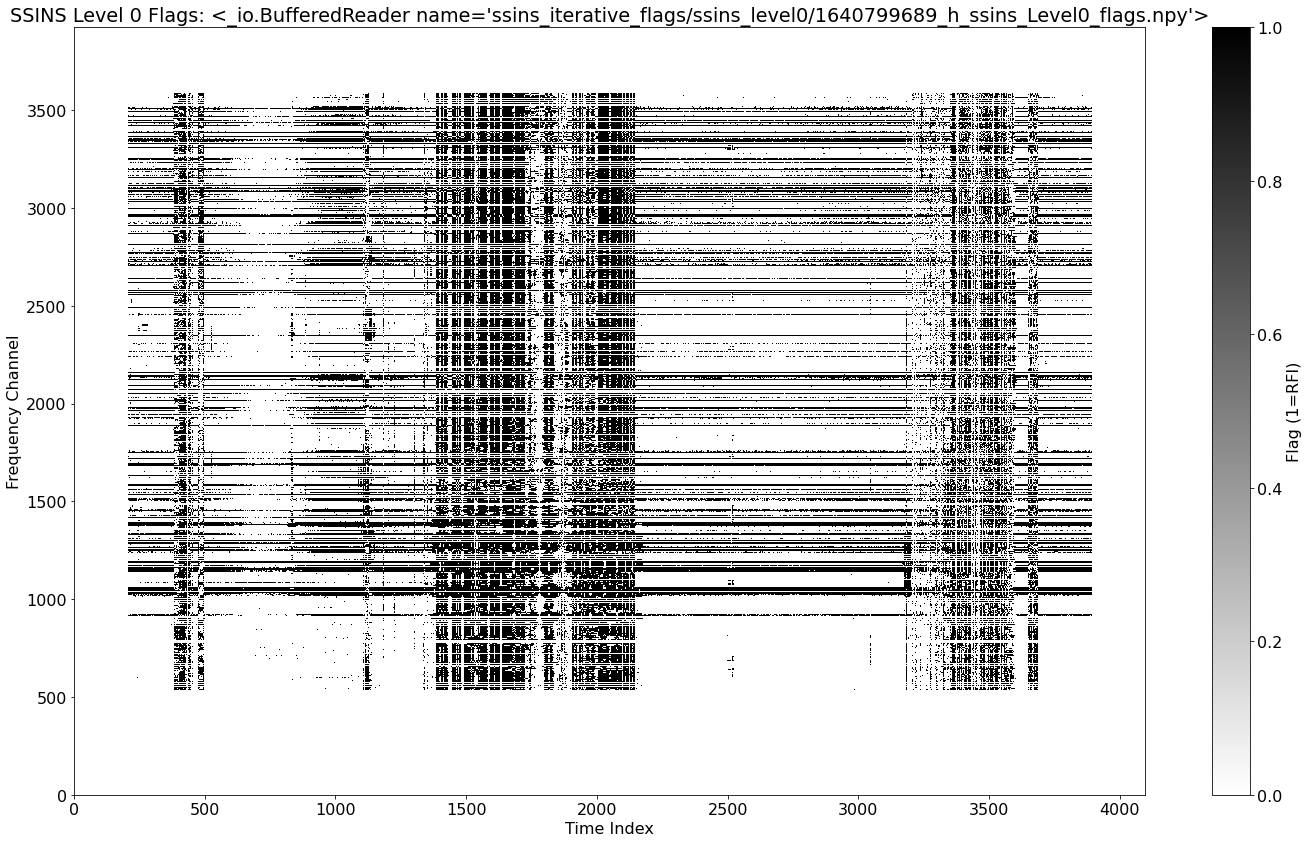

In [14]:

pol = 'h'
for i, f in enumerate(fname): 
    print(f)
    
    data_file = kio.load_data(f)
    ants = [a.name for a in data_file.ants]
    nrec = len(ants)
    freqs = data_file.freqs  # Array of frequencies
    chans = data_file.channels

    with open(f'ssins_iterative_flags/ssins_level0/{f}_{pol}_ssins_Level0_flags.npy', 'rb') as f:
        ssins_flags_round_1 = np.load(f, allow_pickle=True)

    plt.figure(figsize=(20, 12))
    plt.imshow(ssins_flags_round_1, aspect='auto', interpolation='none', origin='lower', cmap='gray_r')    
    plt.title(f'SSINS Level 0 Flags: {f}')
    plt.xlabel('Time Index')
    plt.ylabel('Frequency Channel')
    plt.colorbar(label='Flag (1=RFI)')
    plt.tight_layout()
    plt.show()

    

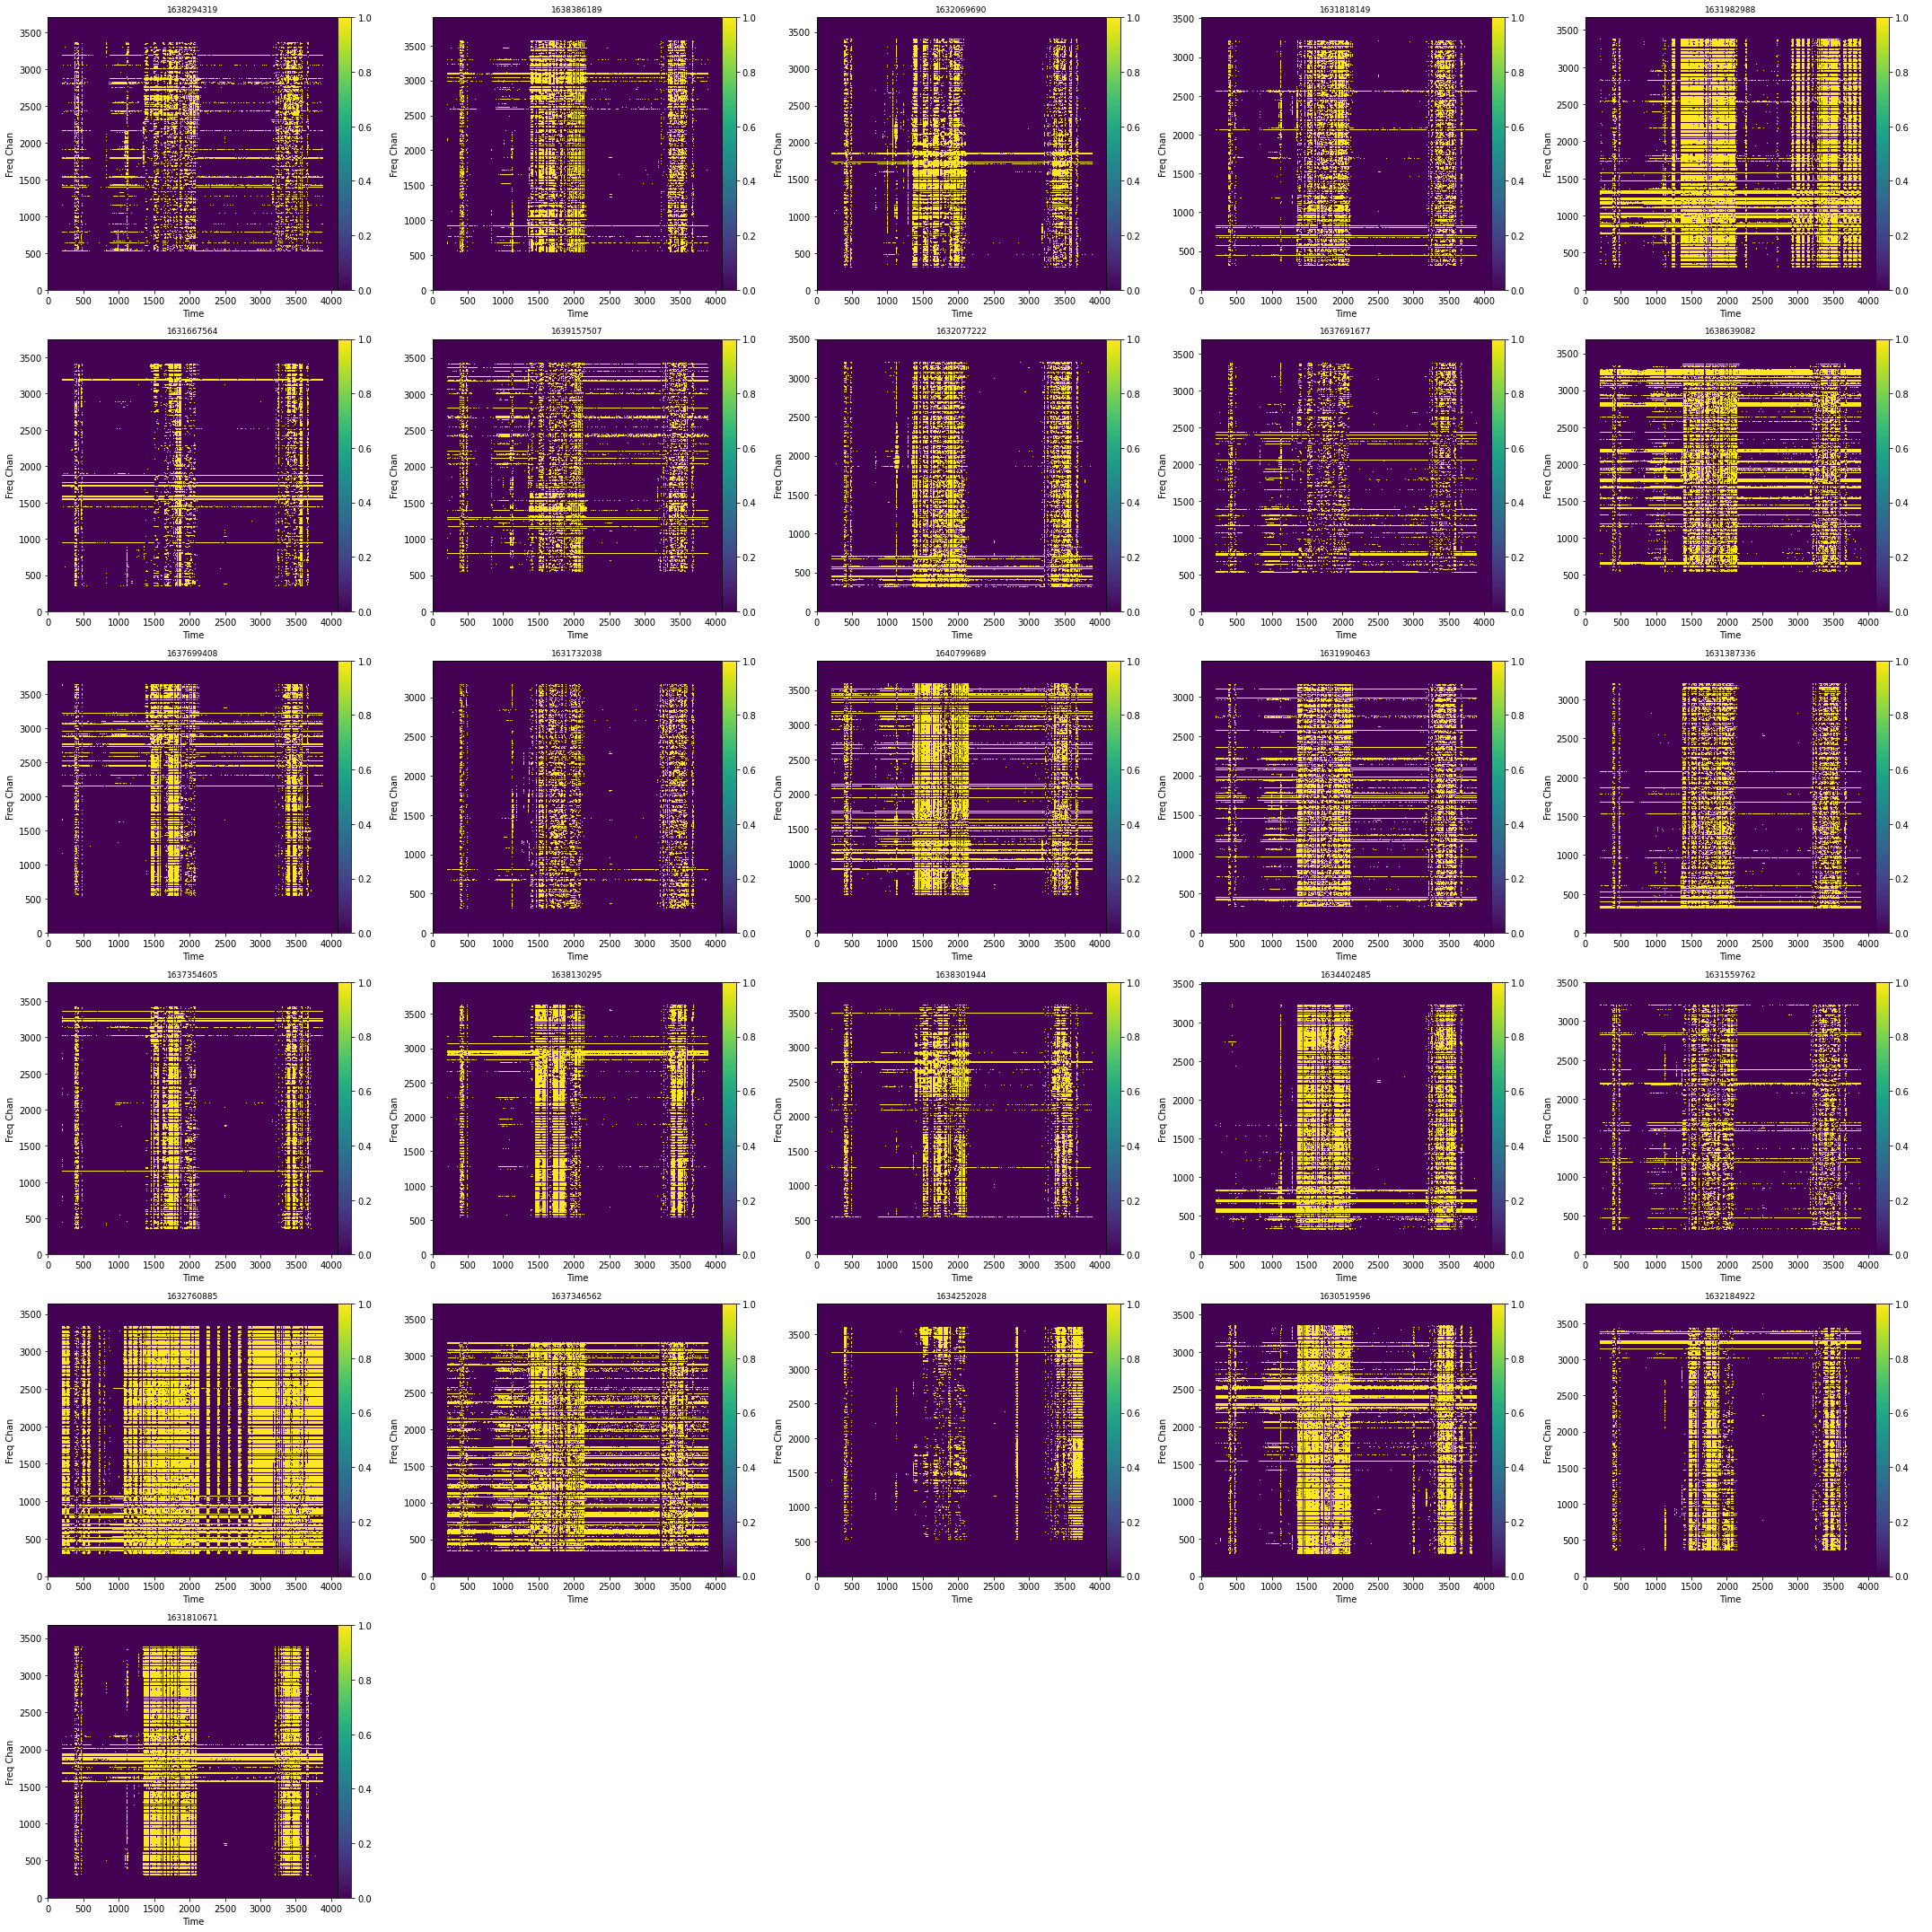

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Example setup
rows = 6
columns = 5
pol = 'h'

fig, axes = plt.subplots(nrows=rows, ncols=columns, figsize=(columns*6, rows*5))

# Flatten axes for easy indexing, even if axes is 2D
axes_flat = axes.flatten()

# Loop through files and axes, plot images + colorbars
for i, (f, ax) in enumerate(zip(fname, axes_flat)):
    #print(f)
    with open(f'ssins_iterative_flags/ssins_level0/{f}_{pol}_ssins_Level0_flags.npy', 'rb') as flag_file:
        ssins_flags = np.load(flag_file, allow_pickle=True)

    im = ax.imshow(ssins_flags, aspect='auto', interpolation='none', origin='lower', vmin=0, vmax=1)
    ax.set_title(f'{f}', fontsize=9)
    ax.set_xlabel('Time')
    ax.set_ylabel('Freq Chan')

    # Add individual colorbar next to each subplot
    cbar = fig.colorbar(im, ax=ax, pad=0)
    #cbar.set_label('Flag (1=RFI)')

# Turn off any unused axes
for ax in axes_flat[len(fname):]:
    ax.axis('off')

f#ig.suptitle(f'SSINS Level 0 Flag Wall (Pol: {pol})', fontsize=16)
fig.tight_layout()  # leave room for suptitle
plt.show()


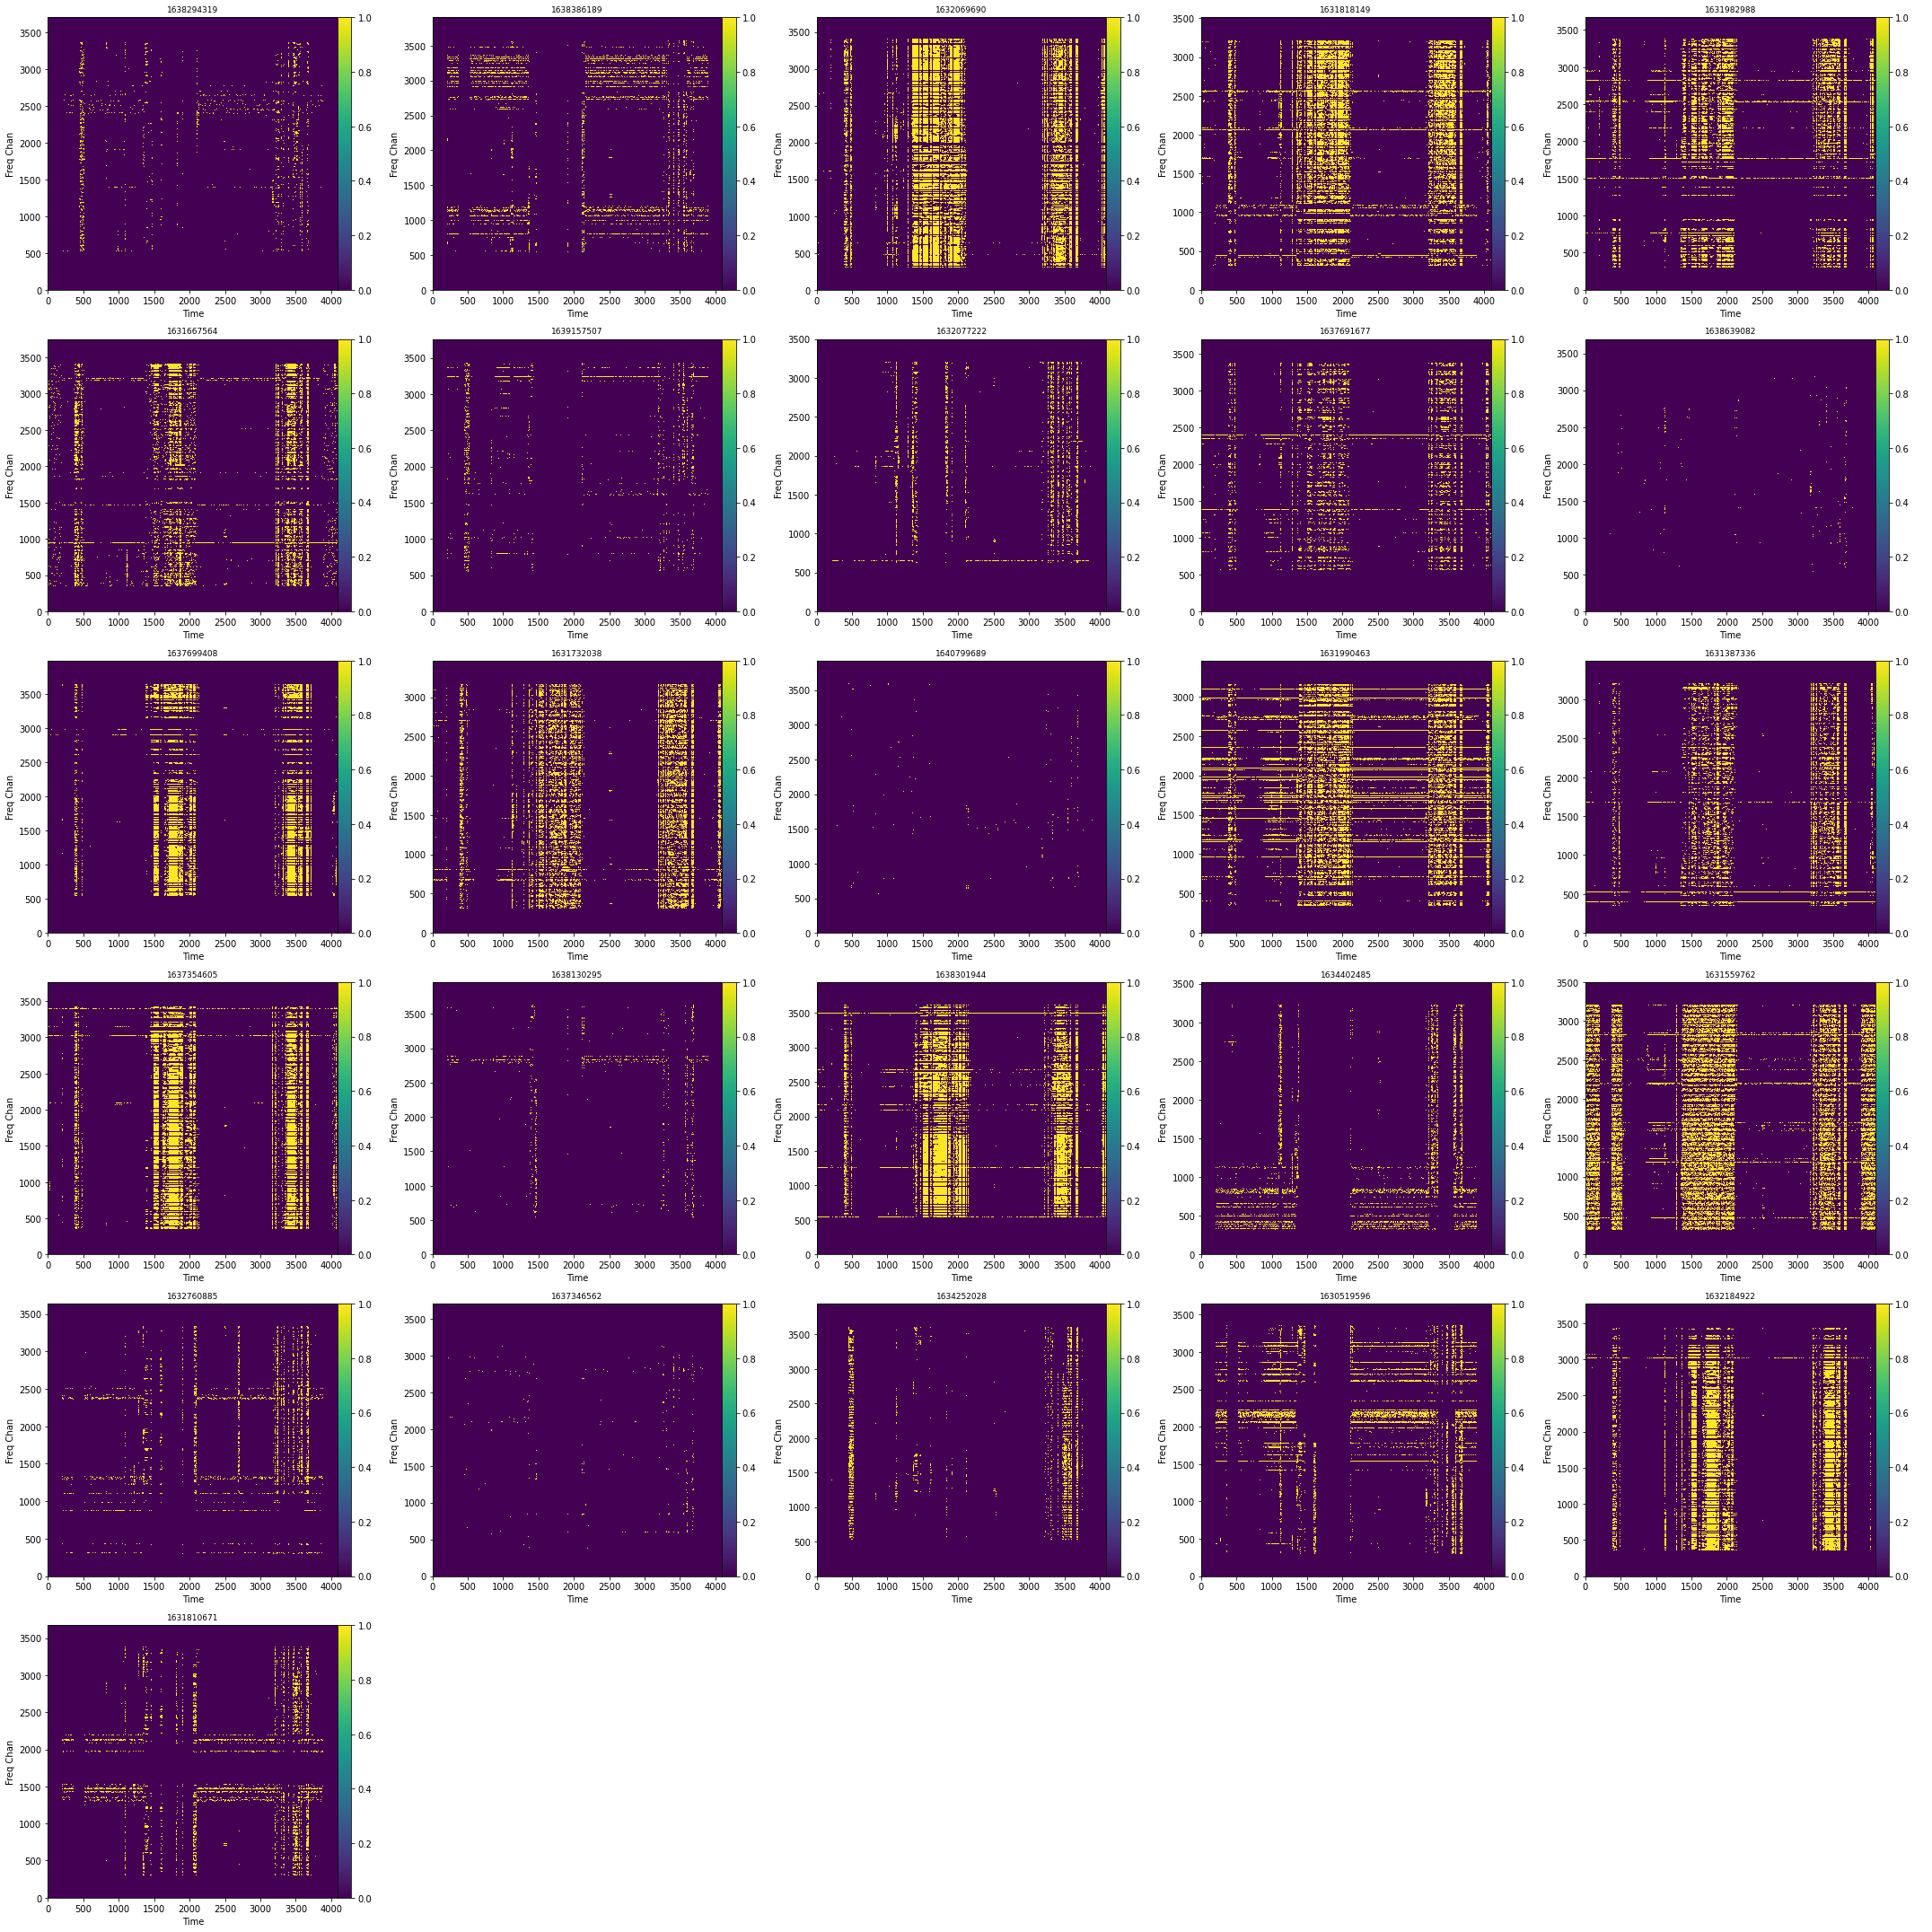

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Example setup
rows = 6
columns = 5
pol = 'h'

fig, axes = plt.subplots(nrows=rows, ncols=columns, figsize=(columns*6, rows*5))

# Flatten axes for easy indexing, even if axes is 2D
axes_flat = axes.flatten()

# Loop through files and axes, plot images + colorbars
for i, (f, ax) in enumerate(zip(fname, axes_flat)):
    #print(f)
    with open(f'ssins_iterative_flags/ssins_level1/{f}_{pol}_ssins_Level1_flags.npy', 'rb') as flag_file:
        ssins_flags = np.load(flag_file, allow_pickle=True)

    im = ax.imshow(ssins_flags, aspect='auto', interpolation='none', origin='lower', vmin=0, vmax=1)
    ax.set_title(f'{f}', fontsize=9)
    ax.set_xlabel('Time')
    ax.set_ylabel('Freq Chan')

    # Add individual colorbar next to each subplot
    cbar = fig.colorbar(im, ax=ax, pad=0)
    #cbar.set_label('Flag (1=RFI)')

# Turn off any unused axes
for ax in axes_flat[len(fname):]:
    ax.axis('off')

f#ig.suptitle(f'SSINS Level 0 Flag Wall (Pol: {pol})', fontsize=16)
fig.tight_layout()  # leave room for suptitle
plt.show()


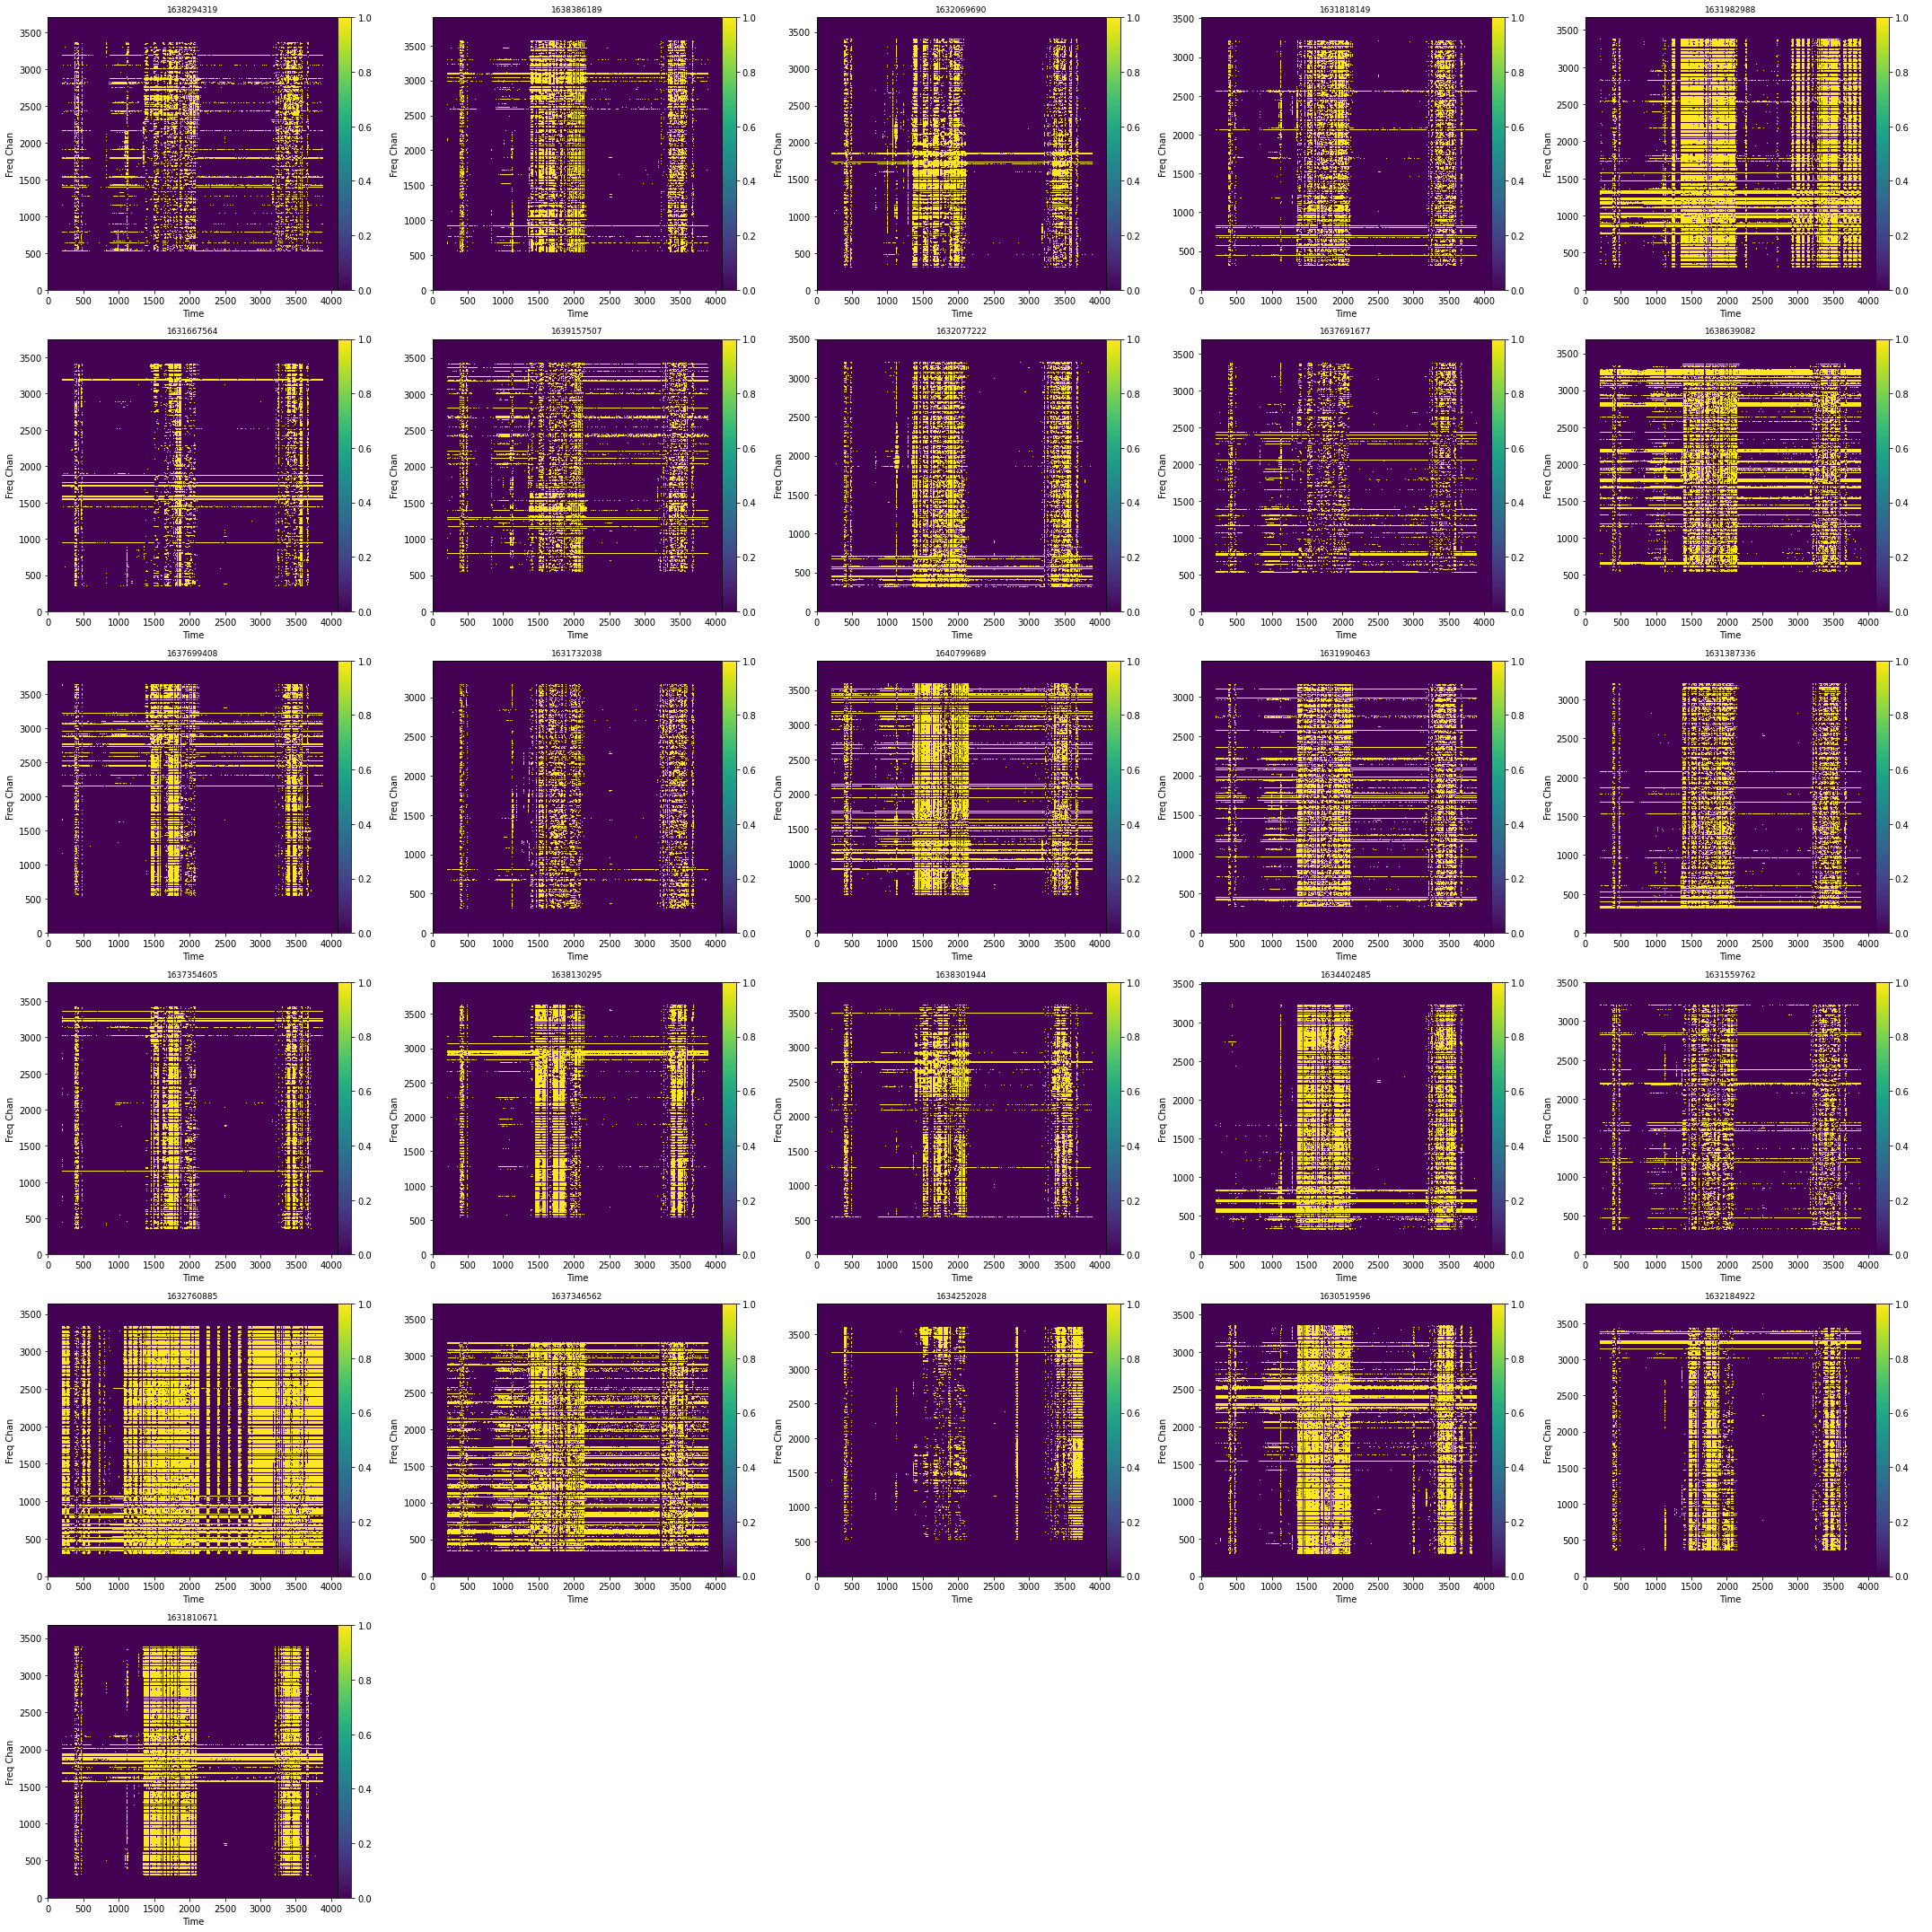

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Example setup
rows = 6
columns = 5
pol = 'h'

fig, axes = plt.subplots(nrows=rows, ncols=columns, figsize=(columns*6, rows*5))

# Flatten axes for easy indexing, even if axes is 2D
axes_flat = axes.flatten()

# Loop through files and axes, plot images + colorbars
for i, (f, ax) in enumerate(zip(fname, axes_flat)):
    #print(f)
    with open(f'ssins_iterative_flags/ssins_level0/{f}_{pol}_ssins_Level0_flags.npy', 'rb') as flag_file:
        ssins_flags = np.load(flag_file, allow_pickle=True)

    with open(f'ssins_iterative_flags/ssins_level1/{f}_{pol}_ssins_Level1_flags.npy', 'rb') as flag_file:
        ssins_flags_1 = np.load(flag_file, allow_pickle=True)

    im = ax.imshow(ssins_flags, aspect='auto', interpolation='none', origin='lower', vmin=0, vmax=1)
    im = ax.imshow(ssins_flags_1, aspect='auto', interpolation='none', origin='lower', vmin=0, vmax=1)
    im = ax.imshow(ssins_flags&ssins_flags_1, aspect='auto', interpolation='none', origin='lower', vmin=0, vmax=1)
    ax.set_title(f'{f}', fontsize=9)
    ax.set_xlabel('Time')
    ax.set_ylabel('Freq Chan')

    # Add individual colorbar next to each subplot
    cbar = fig.colorbar(im, ax=ax, pad=0)
    #cbar.set_label('Flag (1=RFI)')

# Turn off any unused axes
for ax in axes_flat[len(fname):]:
    ax.axis('off')

f#ig.suptitle(f'SSINS Level 0 Flag Wall (Pol: {pol})', fontsize=16)
fig.tight_layout()  # leave room for suptitle
plt.show()


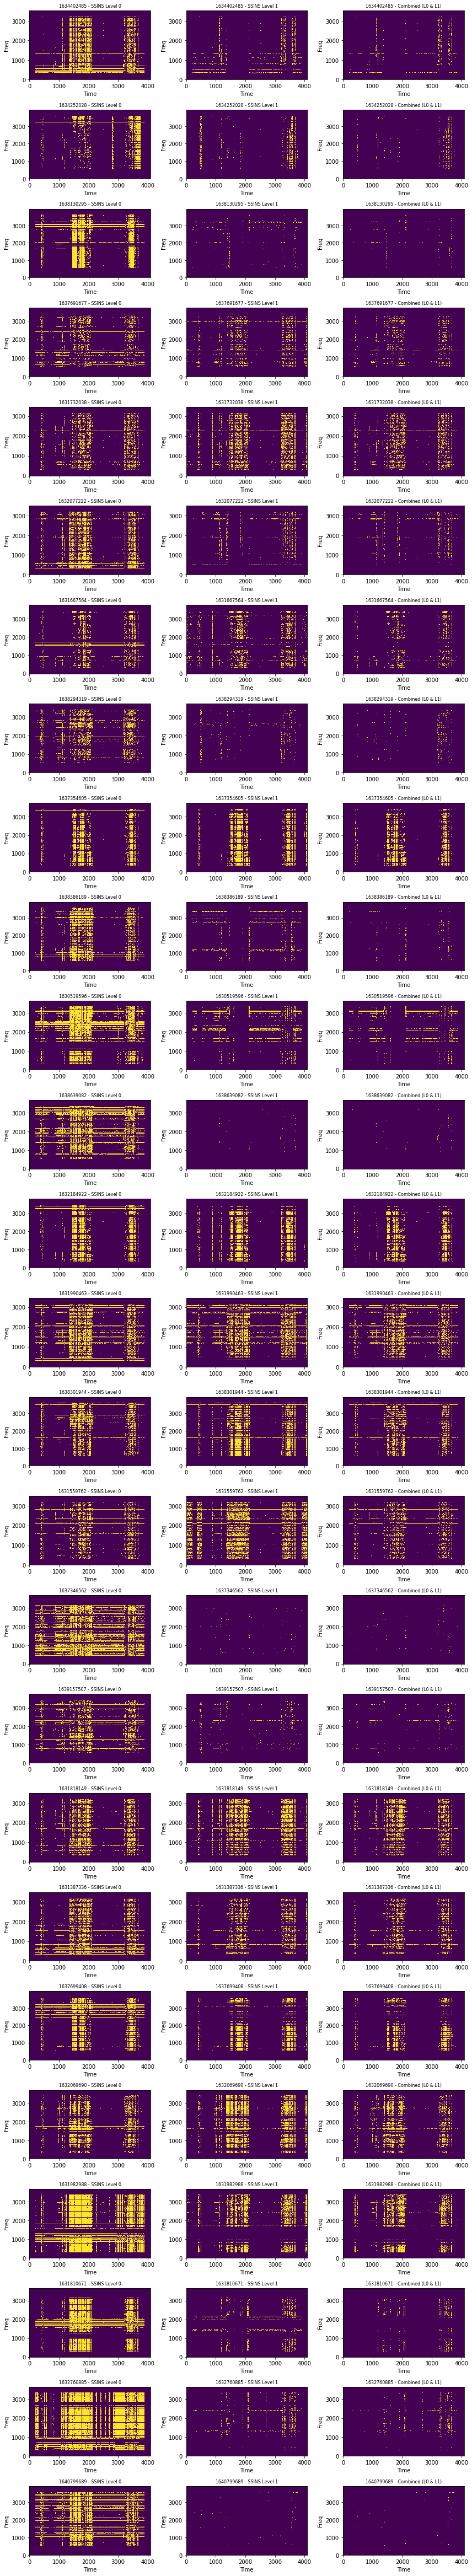

In [6]:
import matplotlib.pyplot as plt
import numpy as np

pol = 'h'
n_files = len(fname)

# Make 3 subplots per file (L0, L1, L0 & L1)
fig, axes = plt.subplots(nrows=n_files, ncols=3, figsize=(12, n_files * 2.5))

# Handle the case where there's only one file (axes is 1D)
if n_files == 1:
    axes = axes[np.newaxis, :]

for i, f in enumerate(fname):
    # Load SSINS flags
    ssins_flags = np.load(f'ssins_iterative_flags/ssins_level0/{f}_{pol}_ssins_Level0_flags.npy', allow_pickle=True)
    ssins_flags_1 = np.load(f'ssins_iterative_flags/ssins_level1/{f}_{pol}_ssins_Level1_flags.npy', allow_pickle=True)
    combined_flags = ssins_flags & ssins_flags_1

    flags_list = [ssins_flags, ssins_flags_1, combined_flags]
    titles = ['SSINS Level 0', 'SSINS Level 1', 'Combined (L0 & L1)']

    for j in range(3):
        ax = axes[i, j]
        im = ax.imshow(flags_list[j], aspect='auto', origin='lower', interpolation='nearest')
        ax.set_title(f'{f} - {titles[j]}', fontsize=8)
        ax.set_xlabel('Time')
        ax.set_ylabel('Freq')

# Optional: turn off unused axes if fname is shorter than expected
if axes.shape[0] > n_files:
    for ax_row in axes[n_files:]:
        for ax in ax_row:
            ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# do the combine waterfall with the different colors for each flags and the combine 

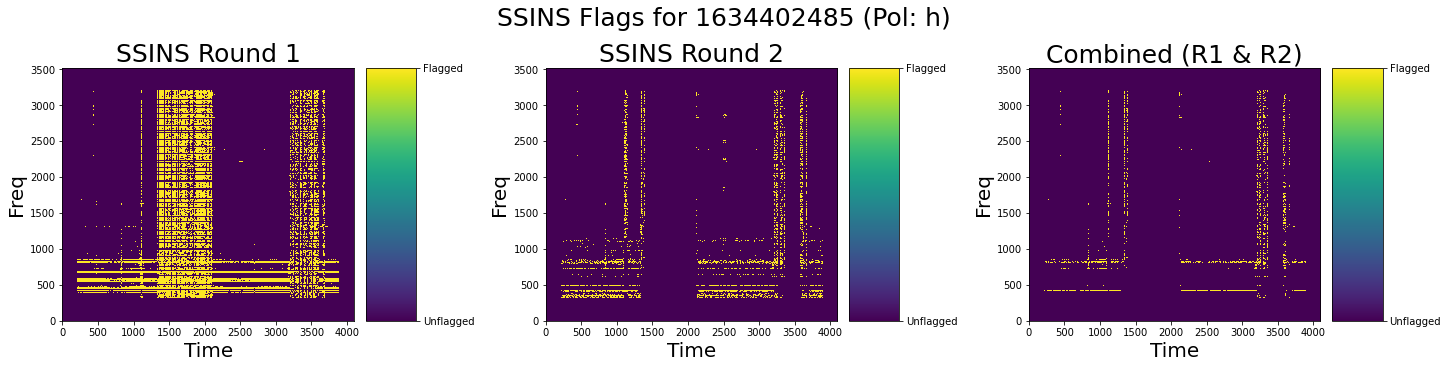

In [28]:
import matplotlib.pyplot as plt
import numpy as np

pol = 'h'

for f in fname[0:1]:
    # Load SSINS flag arrays
    ssins_flags = np.load(f'ssins_iterative_flags/ssins_level0/{f}_{pol}_ssins_Level0_flags.npy', allow_pickle=True)
    ssins_flags_1 = np.load(f'ssins_iterative_flags/ssins_level1/{f}_{pol}_ssins_Level1_flags.npy', allow_pickle=True)
    combined_flags = ssins_flags & ssins_flags_1

    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)

    # Titles and data for iteration
    titles = ['SSINS Round 1', 'SSINS Round 2', 'Combined (R1 & R2)']
    flag_sets = [ssins_flags, ssins_flags_1, combined_flags]

    for ax, data, title in zip(axes, flag_sets, titles):
        im = ax.imshow(data, aspect='auto', origin='lower', interpolation='none', vmin=0, vmax=1)
        ax.set_title(title, fontsize=25)
        ax.set_xlabel('Time', fontsize=20)
        ax.set_ylabel('Freq', fontsize=20)
        cbar = fig.colorbar(im, ax=ax, pad=0.000)
        cbar.set_ticks([0, 1])
        cbar.set_ticklabels(['Unflagged', 'Flagged'])

    fig.suptitle(f'SSINS Flags for {f} (Pol: {pol})', fontsize=25)
    plt.show()


In [48]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# Custom discrete colormap: 0 = white, 1 = yellow
cmap = ListedColormap(['gray', 'yellow'])
bounds = [-0.5, 0.5, 1.5]  # bin edges for 0 and 1
norm = BoundaryNorm(bounds, cmap.N)

pol = 'h'

for f in fname:
    # Load flags
    ssins_flags = np.load(f'ssins_iterative_flags/ssins_level0/{f}_{pol}_ssins_Level0_flags.npy', allow_pickle=True)
    ssins_flags_1 = np.load(f'ssins_iterative_flags/ssins_level1/{f}_{pol}_ssins_Level1_flags.npy', allow_pickle=True)
    combined_flags = ssins_flags & ssins_flags_1

    # Set up figure
    fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True, dpi=180, sharex=True, sharey=True)
    titles = ['SSINS Round 1 ', 'SSINS Round 2', 'Combined (R1 & R2)']
    flag_sets = [ssins_flags, ssins_flags_1, combined_flags]

    for ax, data, title in zip(axes, flag_sets, titles):
        im = ax.imshow(data, aspect='auto', origin='lower', interpolation='none',
                       cmap=cmap, norm=norm)
        ax.set_title(title, fontsize=18)
        ax.set_xlabel('Time Axis')
        ax.set_ylabel('Frequency Axis')

        # Discrete colorbar
        cbar = fig.colorbar(im, ax=ax, ticks=[0, 1], pad=0.0)
        cbar.ax.set_yticklabels(['Unflagged', 'Flagged'])

        

    fig.suptitle(f'SSINS Flags for {f} (Pol: {pol})', fontsize=20)

    save_path = f'ssins_flags_plot_{f}_{pol}.png'
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f'Saved: {save_path}')

    plt.close(fig)  # 
    
    plt.show()


Saved: ssins_flags_plot_1634402485_h.png
Saved: ssins_flags_plot_1634252028_h.png
Saved: ssins_flags_plot_1638130295_h.png
Saved: ssins_flags_plot_1637691677_h.png
Saved: ssins_flags_plot_1631732038_h.png
Saved: ssins_flags_plot_1632077222_h.png
Saved: ssins_flags_plot_1631667564_h.png
Saved: ssins_flags_plot_1638294319_h.png
Saved: ssins_flags_plot_1637354605_h.png
Saved: ssins_flags_plot_1638386189_h.png
Saved: ssins_flags_plot_1630519596_h.png
Saved: ssins_flags_plot_1638639082_h.png
Saved: ssins_flags_plot_1632184922_h.png
Saved: ssins_flags_plot_1631990463_h.png
Saved: ssins_flags_plot_1638301944_h.png
Saved: ssins_flags_plot_1631559762_h.png
Saved: ssins_flags_plot_1637346562_h.png
Saved: ssins_flags_plot_1639157507_h.png
Saved: ssins_flags_plot_1631818149_h.png
Saved: ssins_flags_plot_1631387336_h.png
Saved: ssins_flags_plot_1637699408_h.png
Saved: ssins_flags_plot_1632069690_h.png
Saved: ssins_flags_plot_1631982988_h.png
Saved: ssins_flags_plot_1631810671_h.png
Saved: ssins_fla